In [1]:
import pandas as pd
import numpy as np

In [2]:
loan_data_backup=pd.read_csv("C:\\Users\\aswin\\Downloads\\loan_data_2007_2014.csv")

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\1782330076.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_data_backup=pd.read_csv("C:\\Users\\aswin\\Downloads\\loan_data_2007_2014.csv")


In [3]:

loan_data=loan_data_backup.copy()

In [4]:
loan_data

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,...,NaN,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN
466281,466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,...,NaN,NaN,NaN,NaN,NaN,NaN,39400.0,NaN,NaN,NaN
466282,466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,...,NaN,NaN,NaN,NaN,NaN,NaN,13100.0,NaN,NaN,NaN
466283,466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,...,NaN,NaN,NaN,NaN,NaN,NaN,53100.0,NaN,NaN,NaN


In [5]:

pd.options.display.max_columns = None

In [6]:
loan_data['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [7]:
loan_data['emp_length_int']=(loan_data['emp_length'].str.replace('10+ years','10',regex=False).str.replace('years','',regex=False).str.replace('year','',regex=False).str.replace('< 1','0', regex=False)).str.replace('n/a','0',regex=False).str.strip()

In [8]:
loan_data['emp_length_int'].unique()

array(['10', '0', '1', '3', '8', '9', '4', '5', '6', '2', '7', nan],
      dtype=object)

In [9]:
loan_data['emp_length_int']= pd.to_numeric(loan_data['emp_length_int'])

In [10]:
loan_data['earliest_cr_line_date']=pd.to_datetime(loan_data['earliest_cr_line'],format='%b-%y')

In [11]:
loan_data['earliest_cr_line_date']

0        1985-01-01
1        1999-04-01
2        2001-11-01
3        1996-02-01
4        1996-01-01
            ...    
466280   2003-04-01
466281   1997-06-01
466282   2001-12-01
466283   2003-02-01
466284   2000-02-01
Name: earliest_cr_line_date, Length: 466285, dtype: datetime64[ns]

In [12]:
pd.to_datetime('2017-12-01')-loan_data['earliest_cr_line_date']

0        12022 days
1         6819 days
2         5874 days
3         7974 days
4         8005 days
            ...    
466280    5358 days
466281    7488 days
466282    5844 days
466283    5417 days
466284    6513 days
Name: earliest_cr_line_date, Length: 466285, dtype: timedelta64[ns]

In [13]:
loan_data['month_since_earliest_cr_line']=round(pd.to_numeric((pd.to_datetime('2017-12-01')-loan_data['earliest_cr_line_date']).dt.days/30))

In [14]:
loan_data['month_since_earliest_cr_line'].describe()

count    466256.000000
mean        242.979220
std          95.344015
min        -621.000000
25%         186.000000
50%         228.000000
75%         289.000000
max         596.000000
Name: month_since_earliest_cr_line, dtype: float64

In [15]:
loan_data.loc[ :,['earliest_cr_line','earliest_cr_line_date','month_since_earliest_cr_line']][loan_data['month_since_earliest_cr_line']<0]

,earliest_cr_line,earliest_cr_line_date,month_since_earliest_cr_line
1580,Sep-62,2062-09-01,-545.0
1770,Sep-68,2068-09-01,-618.0
2799,Sep-64,2064-09-01,-569.0
3282,Sep-67,2067-09-01,-606.0
3359,Feb-65,2065-02-01,-574.0
...,...,...,...
464003,Jan-68,2068-01-01,-610.0
464260,Jul-66,2066-07-01,-591.0
465100,Oct-67,2067-10-01,-607.0
465500,Sep-67,2067-09-01,-606.0


In [16]:
loan_data.loc[loan_data['month_since_earliest_cr_line']<0,'month_since_earliest_cr_line']=loan_data['month_since_earliest_cr_line'].max()

In [17]:



min(loan_data['month_since_earliest_cr_line'])

74.0

In [18]:
loan_data['term_int']=loan_data['term'].str.replace('months','').astype(int)

In [19]:


loan_data['term_int']

0         36
1         60
2         36
3         36
4         60
          ..
466280    60
466281    60
466282    60
466283    36
466284    36
Name: term_int, Length: 466285, dtype: int64

In [20]:
loan_data['issue_date']=pd.to_datetime(loan_data['issue_d'],format='%b-%y')

In [21]:
loan_data['issue_date']

0        2011-12-01
1        2011-12-01
2        2011-12-01
3        2011-12-01
4        2011-12-01
            ...    
466280   2014-01-01
466281   2014-01-01
466282   2014-01-01
466283   2014-01-01
466284   2014-01-01
Name: issue_date, Length: 466285, dtype: datetime64[ns]

In [22]:
loan_data['month_since_issue_d']=(pd.to_datetime('2017-12-01')-loan_data['issue_date']).dt.days/30

In [23]:
loan_data['month_since_issue_d']

0         73.066667
1         73.066667
2         73.066667
3         73.066667
4         73.066667
            ...    
466280    47.666667
466281    47.666667
466282    47.666667
466283    47.666667
466284    47.666667
Name: month_since_issue_d, Length: 466285, dtype: float64

In [24]:
loan_data_dummies=[pd.get_dummies(loan_data['grade'],prefix='grade',prefix_sep=':'),
                  pd.get_dummies(loan_data['sub_grade'],prefix='sub_grade',prefix_sep=':'),
                  pd.get_dummies(loan_data['home_ownership'],prefix='home_ownership',prefix_sep=':'),
                  pd.get_dummies(loan_data['verification_status'],prefix='verification_status',prefix_sep=':'),
                  pd.get_dummies(loan_data['loan_status'],prefix='loan_status',prefix_sep=':'),
                  pd.get_dummies(loan_data['purpose'],prefix='purpose',prefix_sep=':'),
                  pd.get_dummies(loan_data['addr_state'],prefix='addr_state',prefix_sep=':'),
                  pd.get_dummies(loan_data['initial_list_status'],prefix='initial_list_status',prefix_sep=':')]

In [25]:


loan_data_dummies=pd.concat(loan_data_dummies,axis=1)

In [26]:
loan_data=pd.concat([loan_data,loan_data_dummies],axis=1)

In [27]:

loan_data.columns.values

array(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'veri

In [28]:
loan_data.isnull()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,earliest_cr_line_date,month_since_earliest_cr_line,term_int,issue_date,month_since_issue_d,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,True,True,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [29]:

pd.options.display.max_rows=None
loan_data.isnull().sum()

Unnamed: 0                                                              0
id                                                                      0
member_id                                                               0
loan_amnt                                                               0
funded_amnt                                                             0
funded_amnt_inv                                                         0
term                                                                    0
int_rate                                                                0
installment                                                             0
grade                                                                   0
sub_grade                                                               0
emp_title                                                           27588
emp_length                                                          21008
home_ownership                        

In [30]:
pd.options.display.max_rows=100

In [31]:
loan_data['total_rev_hi_lim'].fillna(loan_data['funded_amnt'],inplace=True)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\991546610.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data['total_rev_hi_lim'].fillna(loan_data['funded_amnt'],inplace=True)


In [32]:
loan_data['total_rev_hi_lim'].isnull().sum()

np.int64(0)

In [33]:
loan_data['annual_inc']=loan_data['annual_inc'].fillna(loan_data['annual_inc'].mean())

In [34]:

loan_data['annual_inc'].isnull().sum()

np.int64(0)

In [35]:
loan_data['open_acc']=loan_data['open_acc'].fillna('0')

In [36]:

loan_data['open_acc'].isnull().sum()

np.int64(0)

In [37]:
loan_data['delinq_2yrs']=loan_data['delinq_2yrs'].fillna('0')

In [38]:
loan_data['inq_last_6mths']=loan_data['inq_last_6mths'].fillna('0')
loan_data['total_acc']=loan_data['total_acc'].fillna('0')
loan_data['pub_rec']=loan_data['pub_rec'].fillna('0')
loan_data['inq_last_6mths']=loan_data['inq_last_6mths'].fillna('0')
loan_data['acc_now_delinq']=loan_data['acc_now_delinq'].fillna('0')
loan_data['emp_length_int']=loan_data['emp_length_int'].fillna('0')
loan_data['open_acc']=loan_data['open_acc'].fillna('0')

In [39]:
loan_data['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [40]:

loan_data['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [41]:

loan_data['loan_status'].value_counts()/loan_data['loan_status'].count()

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: count, dtype: float64

In [42]:
loan_data['good_bad']=np.where(loan_data['loan_status'].isin(['Charged Off','Late (31-120 days)','Default','Does not meet the credit policy. Status:Charged Off']),0,1)

In [43]:
loan_data['good_bad']

0         1
1         0
2         1
3         1
4         1
         ..
466280    1
466281    0
466282    1
466283    1
466284    1
Name: good_bad, Length: 466285, dtype: int64

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
train_test_split(loan_data.drop('good_bad',axis=1),loan_data['good_bad'])

[        Unnamed: 0        id  member_id  loan_amnt  funded_amnt  \
 128334      128334   5774606    7206759      12000        12000   
 14146        14146    770806     972516       8875         8875   
 138230      138230   3005412    3637632      18000        18000   
 389260      389260  16501661   18604158       6600         6600   
 27651        27651    550956     710110       7000         7000   
 ...            ...       ...        ...        ...          ...   
 335069      335069  22454468   24777113      26000        26000   
 12              12   1064687    1298717       9000         9000   
 22707        22707    625832     801994       3000         3000   
 367975      367975  19146230   21348953      12500        12500   
 422069      422069  12988655   15020807      14000        14000   
 
         funded_amnt_inv        term  int_rate  installment grade sub_grade  \
 128334          12000.0   36 months     14.33       412.06     C        C1   
 14146            8875.0

In [46]:
loan_data_inputs_train,loan_data_inputs_test,loan_data_targets_train,loan_data_targets_test=train_test_split(loan_data.drop('good_bad',axis=1),loan_data['good_bad'])

In [47]:

loan_data_targets_train=pd.DataFrame(loan_data_targets_train)
loan_data_targets_test=pd.DataFrame(loan_data_targets_test)

In [48]:
type(loan_data_targets_test)

pandas.core.frame.DataFrame

In [49]:
loan_data_inputs_train.shape

(349713, 207)

In [50]:

loan_data_targets_train.shape

(349713, 1)

In [51]:
loan_data_targets_test.shape

(116572, 1)

In [52]:
loan_data_inputs_test.shape

(116572, 207)

In [53]:
loan_data_inputs_train,loan_data_inputs_test,loan_data_targets_train,loan_data_targets_test=train_test_split(loan_data.drop('good_bad',axis=1),loan_data['good_bad'],test_size=0.2,random_state = 42)

In [54]:
loan_data_targets_test=pd.DataFrame(loan_data_targets_test)
loan_data_targets_train=pd.DataFrame(loan_data_targets_train)

In [55]:

loan_data_inputs_train.shape

(373028, 207)

In [56]:
loan_data_targets_train.shape

(373028, 1)

In [57]:
loan_data_inputs_test.shape

(93257, 207)

In [58]:
loan_data_targets_test.shape

(93257, 1)

In [59]:
df_inputs_prepr=loan_data_inputs_train
df_targets_prepr=loan_data_targets_train

In [60]:
df_inputs_prepr['grade'].unique()

array(['A', 'C', 'D', 'B', 'E', 'F', 'G'], dtype=object)

In [61]:



df1=pd.concat([df_inputs_prepr['grade'],df_targets_prepr],axis=1)
df1.head()

,grade,good_bad
427211,A,1
206088,C,1
136020,A,1
412305,D,0
36159,C,0


In [62]:

df1.groupby(df1.columns.values[0],as_index=False)[df1.columns.values[1]].count()

,grade,good_bad
0,A,59759
1,B,109730
2,C,100245
3,D,61498
4,E,28612
5,F,10530
6,G,2654


In [63]:
df1.groupby(df1.columns.values[0],as_index=False)[df1.columns.values[1]].mean()

,grade,good_bad
0,A,0.961044
1,B,0.921015
2,C,0.885770
3,D,0.846304
4,E,0.805257
5,F,0.754416
6,G,0.727958


In [64]:
df1=pd.concat([df1.groupby(df1.columns.values[0],as_index=False)[df1.columns.values[1]].count(),df1.groupby(df1.columns.values[0],as_index=False)[df1.columns.values[1]].mean()],axis=1)

In [65]:
df1

,grade,good_bad,grade,good_bad
0,A,59759,A,0.961044
1,B,109730,B,0.921015
2,C,100245,C,0.885770
3,D,61498,D,0.846304
4,E,28612,E,0.805257
5,F,10530,F,0.754416
6,G,2654,G,0.727958


In [66]:
df1 = df1.iloc[:,[0,1,3]]
df1

,grade,good_bad,good_bad
0,A,59759,0.961044
1,B,109730,0.921015
2,C,100245,0.885770
3,D,61498,0.846304
4,E,28612,0.805257
5,F,10530,0.754416
6,G,2654,0.727958


In [67]:
df1.columns=[df1.columns.values[0],'n_obs','prop_good']
df1

,grade,n_obs,prop_good
0,A,59759,0.961044
1,B,109730,0.921015
2,C,100245,0.885770
3,D,61498,0.846304
4,E,28612,0.805257
5,F,10530,0.754416
6,G,2654,0.727958


In [68]:
df1['prop_n_obs']=df1['n_obs']/df1['n_obs'].sum()

In [69]:
df1

,grade,n_obs,prop_good,prop_n_obs
0,A,59759,0.961044,0.160200
1,B,109730,0.921015,0.294160
2,C,100245,0.885770,0.268733
3,D,61498,0.846304,0.164862
4,E,28612,0.805257,0.076702
5,F,10530,0.754416,0.028228
6,G,2654,0.727958,0.007115


In [70]:
df1['prop_bad']=1-df1['prop_good']

In [71]:


df1['n_good']= df1['n_obs']*df1['prop_good']
df1['n_bad']=df1['n_obs']*df1['prop_bad']


In [72]:
total_good=df1['n_good'].sum()
total_bad=df1['n_bad'].sum()

In [73]:
df1['dist_good']=df1['n_good']/total_good
df1['dist_bad']=df1['n_bad']/total_bad

In [74]:
df1['WOE']=np.log(df1['dist_good']/df1['dist_bad'])

In [75]:
df1['IV']=(df1['dist_good']-df1['dist_bad'])*df1['WOE']

In [76]:
df1['IV']

0    0.128248
1    0.032850
2    0.000671
3    0.029445
4    0.045645
5    0.038537
6    0.013240
Name: IV, dtype: float64

In [77]:
def woe_discrete(df,discrete_variable_name,good_bad_variable_df):
    df=pd.concat([df[discrete_variable_name],good_bad_variable_df],axis=1)
    df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
                   df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].mean()],axis=1)
    df = df.iloc[:,[0,1,3]]
    df.columns=[df.columns.values[0],'n_obs','prop_good']
    df['prop_n_obs']=df['n_obs']/df['n_obs'].sum()
    df['prop_bad']=1-df['prop_good']
    df['n_good']= df['n_obs']*df['prop_good']
    df['n_bad']=df['n_obs']*df['prop_bad']
    total_good=df['n_good'].sum()
    total_bad=df['n_bad'].sum()
    df['dist_good']=df['n_good']/total_good
    df['dist_bad']=df['n_bad']/total_bad
    df['WOE']=np.log(df['dist_good']/df['dist_bad'])
    df['IV']=(df['dist_good']-df['dist_bad'])*df['WOE'] 
    return df

In [78]:
df_temp=woe_discrete(df_inputs_prepr,'grade',df_targets_prepr)

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


In [80]:
def plot_by_woe(df_temp,rotation_of_x_axis_labels=0):
    df_temp=df_temp.sort_values(by='WOE')
    x=np.array(df_temp.iloc[:,0].apply(str))
    y=df_temp['WOE']
    plt.figure(figsize=(18,6))
    plt.plot(x,y,marker='o',linestyle='--',color="k")
    plt.xlabel(df_temp.columns[0])
    plt.ylabel('weight_of_evidence')
    plt.title(str('weight of evidence by' +df_temp.columns[0]))
    plt.xticks(rotation=rotation_of_x_axis_labels)

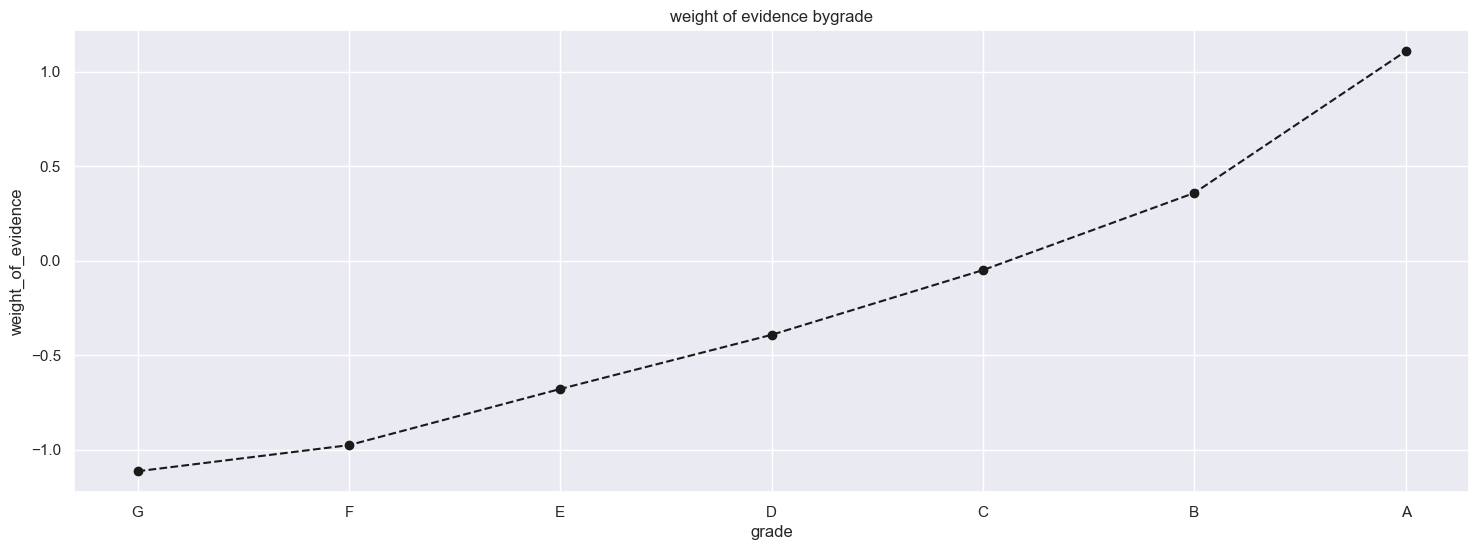

In [81]:
plot_by_woe(df_temp)

In [82]:

df_temp=woe_discrete(df_inputs_prepr,"home_ownership",df_targets_prepr)

In [83]:
df_temp.head()

,home_ownership,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,ANY,1,1.000000,0.000003,0.000000,1.0,0.0,0.000003,0.000000,inf,inf
1,MORTGAGE,188956,0.903835,0.506546,0.096165,170785.0,18171.0,0.514026,0.445608,0.142834,0.009772
2,NONE,40,0.850000,0.000107,0.150000,34.0,6.0,0.000102,0.000147,-0.363144,0.000016
3,OTHER,137,0.795620,0.000367,0.204380,109.0,28.0,0.000328,0.000687,-0.738602,0.000265
4,OWN,33295,0.892536,0.089256,0.107464,29717.0,3578.0,0.089442,0.087743,0.019170,0.000033


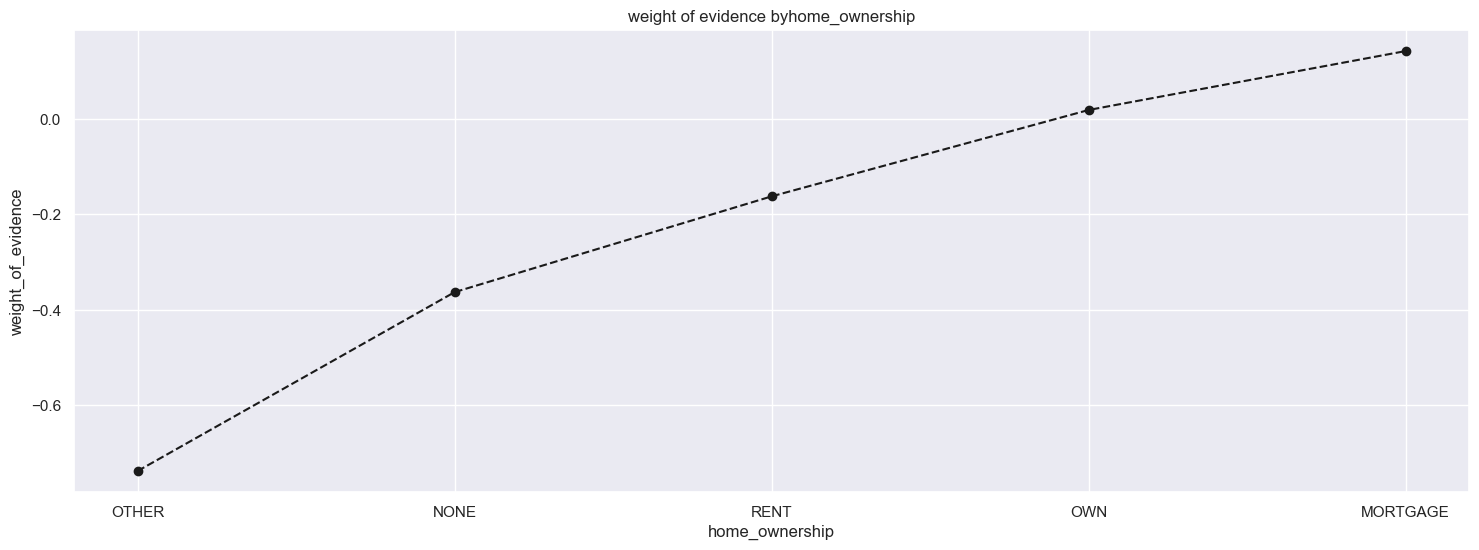

In [84]:
plot_by_woe(df_temp)

In [85]:
df_inputs_prepr['home_ownership:mortgage_other_none_any']=(df_inputs_prepr['home_ownership:MORTGAGE']+df_inputs_prepr['home_ownership:OTHER']+ df_inputs_prepr['home_ownership:NONE']+df_inputs_prepr['home_ownership:ANY'])

In [86]:
df_temp=woe_discrete(df_inputs_prepr,"addr_state",df_targets_prepr)
df_temp.head()

,addr_state,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,AK,1003,0.911266,0.002689,0.088734,914.0,89.0,0.002751,0.002183,0.231449,1.315537e-04
1,AL,4671,0.877328,0.012522,0.122672,4098.0,573.0,0.012334,0.014052,-0.130376,2.239356e-04
2,AR,2760,0.889855,0.007399,0.110145,2456.0,304.0,0.007392,0.007455,-0.008483,5.342513e-07
3,AZ,8645,0.888259,0.023175,0.111741,7679.0,966.0,0.023112,0.023689,-0.024664,1.423445e-05
4,CA,57199,0.885645,0.153337,0.114355,50658.0,6541.0,0.152470,0.160405,-0.050738,4.026352e-04


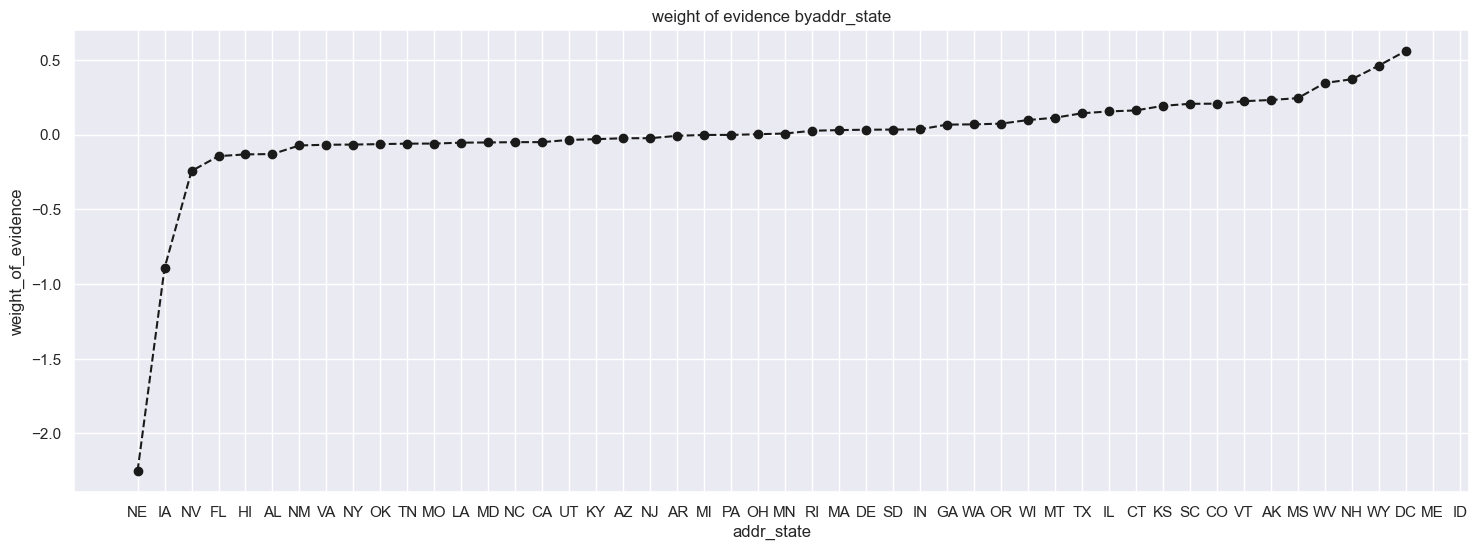

In [87]:
plot_by_woe(df_temp)

In [88]:
if['addr_state=ND']in df_inputs_prepr.columns.values:
    pass
else:
    df_inputs_prepr['addr_state=ND']=0






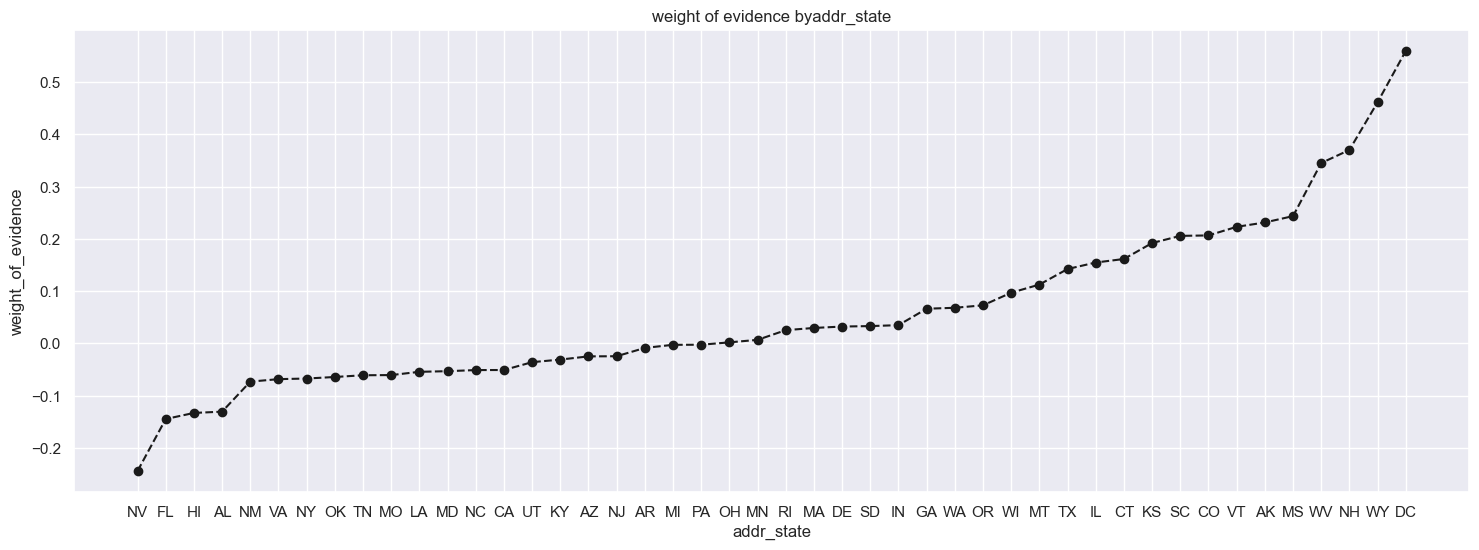

In [89]:
plot_by_woe(df_temp.sort_values(by='WOE').iloc[2:-2,:])

In [90]:
df_inputs_prepr['addr_state:ND_NE_IA_NV_FL_HI_AL']=(df_inputs_prepr['addr_state:NE']+ df_inputs_prepr['addr_state:IA']+df_inputs_prepr['addr_state:NV']+df_inputs_prepr['addr_state:FL']+df_inputs_prepr['addr_state:HI']+df_inputs_prepr['addr_state:AL'])
df_inputs_prepr['addr_state:NM_VA']=(df_inputs_prepr['addr_state:NM']+ df_inputs_prepr['addr_state:VA'])
df_inputs_prepr['addr_state:OK_TN_MO_LA_MD_NC']=(df_inputs_prepr['addr_state:OK']+ df_inputs_prepr['addr_state:TN']+df_inputs_prepr['addr_state:MO']+df_inputs_prepr['addr_state:LA']+df_inputs_prepr['addr_state:MD']+df_inputs_prepr['addr_state:NC'])
df_inputs_prepr['addr_state:UT_KY_AZ_NJ']=(df_inputs_prepr['addr_state:UT']+ df_inputs_prepr['addr_state:KY']+df_inputs_prepr['addr_state:AZ']+df_inputs_prepr['addr_state:NJ'])
df_inputs_prepr['addr_state:AR_MI_PA_OH_MN']=(df_inputs_prepr['addr_state:AR']+ df_inputs_prepr['addr_state:MI']+df_inputs_prepr['addr_state:PA']+df_inputs_prepr['addr_state:OH']+df_inputs_prepr['addr_state:MN'])
df_inputs_prepr['addr_state:RI_MA_DE_SD_IN']=(df_inputs_prepr['addr_state:RI']+ df_inputs_prepr['addr_state:MA']+df_inputs_prepr['addr_state:DE']+df_inputs_prepr['addr_state:SD']+df_inputs_prepr['addr_state:IN'])
df_inputs_prepr['addr_state:GA_WA_OR']=(df_inputs_prepr['addr_state:GA']+ df_inputs_prepr['addr_state:WA']+df_inputs_prepr['addr_state:OR'])
df_inputs_prepr['addr_state:WI_MT']=(df_inputs_prepr['addr_state:WI']+ df_inputs_prepr['addr_state:MT'])
df_inputs_prepr['addr_state:IL_CT']=(df_inputs_prepr['addr_state:IL']+ df_inputs_prepr['addr_state:CT'])
df_inputs_prepr['addr_state:KS_SC_CO_VT_AK_MS']=(df_inputs_prepr['addr_state:KS']+ df_inputs_prepr['addr_state:SC']+df_inputs_prepr['addr_state:CO']+df_inputs_prepr['addr_state:VT']+df_inputs_prepr['addr_state:AK']+df_inputs_prepr['addr_state:MS'])
df_inputs_prepr['addr_state:WV_NH_WY_DC_ME_ID']=(df_inputs_prepr['addr_state:WV']+ df_inputs_prepr['addr_state:NH']+df_inputs_prepr['addr_state:WY']+df_inputs_prepr['addr_state:DC']+df_inputs_prepr['addr_state:ME']+df_inputs_prepr['addr_state:ID'])










In [91]:
def woe_ordered_continuous(df,continuous_variable_name,good_bad_variable_df):
    df=pd.concat([df[continuous_variable_name],good_bad_variable_df],axis=1)
    df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
                   df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].mean()],axis=1)
    df = df.iloc[:,[0,1,3]]
    df.columns=[df.columns.values[0],'n_obs','prop_good']
    df['prop_n_obs']=df['n_obs']/df['n_obs'].sum()
    df['prop_bad']=1-df['prop_good']
    df['n_good']= df['n_obs']*df['prop_good']
    df['n_bad']=df['n_obs']*df['prop_bad']
    total_good=df['n_good'].sum()
    total_bad=df['n_bad'].sum()
    df['dist_good']=df['n_good']/total_good
    df['dist_bad']=df['n_bad']/total_bad
    df['WOE']=np.log(df['dist_good']/df['dist_bad'])
    df['IV']=(df['dist_good']-df['dist_bad'])*df['WOE'] 
    return df

In [92]:
df_inputs_prepr['term_int'].unique()

array([36, 60])

In [93]:
df_temp=woe_ordered_continuous(df_inputs_prepr,'term_int',df_targets_prepr)
df_temp

,term_int,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,36,270419,0.902995,0.724929,0.097005,244187.0,26232.0,0.73495,0.643288,0.133209,0.012210
1,60,102609,0.858239,0.275071,0.141761,88063.0,14546.0,0.26505,0.356712,-0.297009,0.027224


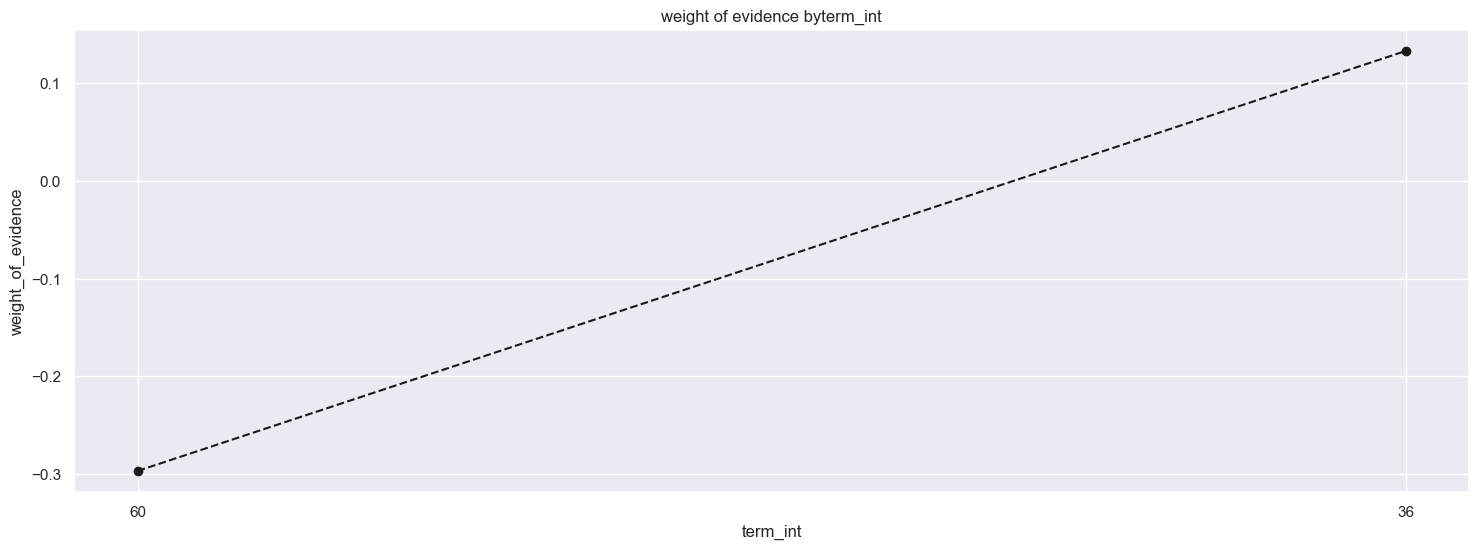

In [94]:
plot_by_woe(df_temp)

In [95]:
df_inputs_prepr['term:36']=np.where((df_inputs_prepr['term_int']==36),1,0)
df_inputs_prepr['term:60']=np.where((df_inputs_prepr['term_int']==60),1,0)

In [96]:
df_inputs_prepr['emp_length_int'].unique()

array([3.0, 6.0, 10.0, 7.0, 5.0, 0.0, 2.0, 9.0, 1.0, 8.0, '0', 4.0],
      dtype=object)

In [97]:
df_temp=woe_ordered_continuous(df_inputs_prepr,'emp_length_int',df_targets_prepr)
df_temp

,emp_length_int,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,0.0,28912,0.881157,0.077506,0.118843,25476.0,3436.0,0.076677,0.084261,-0.094316,7.152862e-04
1,1.0,23654,0.886996,0.063411,0.113004,20981.0,2673.0,0.063148,0.065550,-0.037329,8.965789e-05
2,2.0,33078,0.890955,0.088674,0.109045,29471.0,3607.0,0.088701,0.088455,0.002785,6.872024e-07
3,3.0,29205,0.890772,0.078292,0.109228,26015.0,3190.0,0.078299,0.078228,0.000907,6.444066e-08
4,4.0,22468,0.890644,0.060231,0.109356,20011.0,2457.0,0.060229,0.060253,-0.000404,9.829773e-09
5,5.0,24602,0.884725,0.065952,0.115275,21766.0,2836.0,0.065511,0.069547,-0.059790,2.413379e-04
6,6.0,20887,0.883899,0.055993,0.116101,18462.0,2425.0,0.055567,0.059468,-0.067862,2.647803e-04
7,7.0,21049,0.887453,0.056427,0.112547,18680.0,2369.0,0.056223,0.058095,-0.032759,6.133645e-05
8,8.0,17853,0.889878,0.047860,0.110122,15887.0,1966.0,0.047816,0.048212,-0.008245,3.263866e-06
9,9.0,14267,0.886662,0.038246,0.113338,12650.0,1617.0,0.038074,0.039654,-0.040660,6.424315e-05


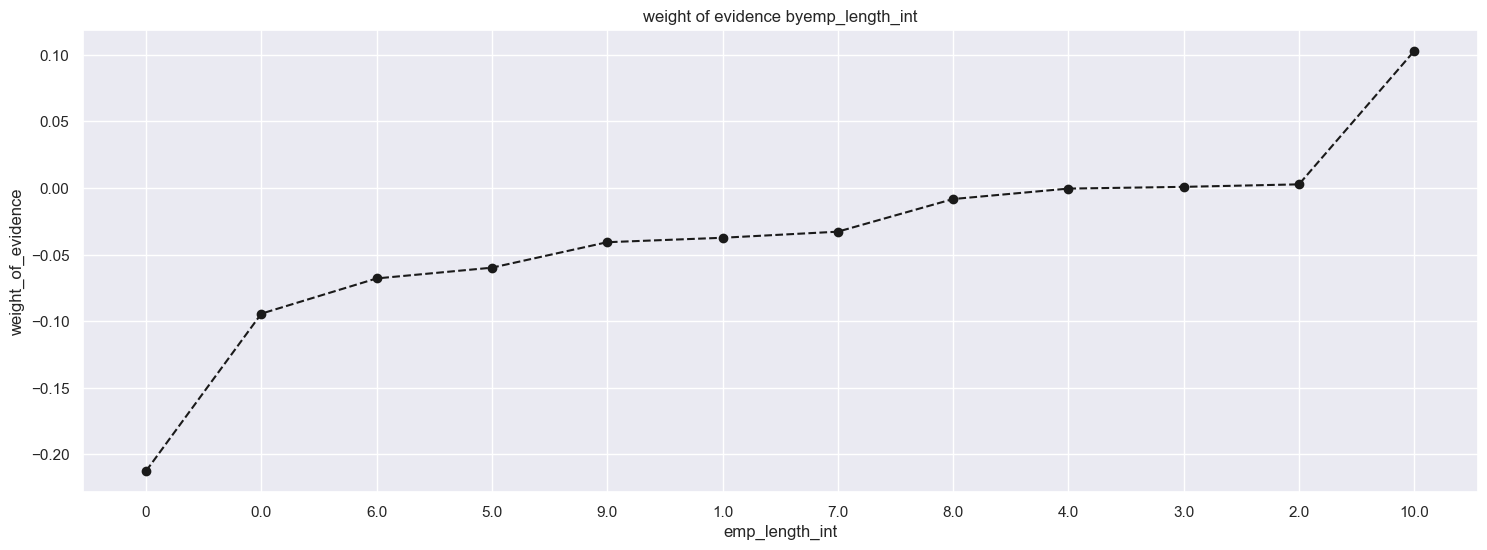

In [98]:
plot_by_woe(df_temp)

In [99]:
df_inputs_prepr['emp_length:0']=np.where(df_inputs_prepr['emp_length_int'].isin([0]),1,0)
df_inputs_prepr['emp_length:1']=np.where(df_inputs_prepr['emp_length_int'].isin([1]),1,0)
df_inputs_prepr['emp_length:2-4']=np.where(df_inputs_prepr['emp_length_int'].isin(range(2,4)),1,0)
df_inputs_prepr['emp_length:5-6']=np.where(df_inputs_prepr['emp_length_int'].isin(range(5,6)),1,0)
df_inputs_prepr['emp_length:7-9']=np.where(df_inputs_prepr['emp_length_int'].isin(range(7,9)),1,0)
df_inputs_prepr['emp_length:10']=np.where(df_inputs_prepr['emp_length_int'].isin([10]),1,0)


In [100]:
df_inputs_prepr['month_since_issue_d_factor']=pd.cut(df_inputs_prepr['month_since_issue_d'],50)

In [101]:
df_inputs_prepr['month_since_issue_d_factor']

427211     (45.667, 47.493]
206088      (63.933, 65.76]
136020       (52.973, 54.8]
412305      (43.84, 45.667]
36159     (102.293, 104.12]
                ...        
259178      (36.442, 38.36]
365838      (42.013, 43.84]
131932       (52.973, 54.8]
146867     (56.627, 58.453]
121958       (52.973, 54.8]
Name: month_since_issue_d_factor, Length: 373028, dtype: category
Categories (50, interval[float64, right]): [(36.442, 38.36] < (38.36, 40.187] < (40.187, 42.013] < (42.013, 43.84] ... (120.56, 122.387] < (122.387, 124.213] < (124.213, 126.04] < (126.04, 127.867]]

In [102]:
df_temp=woe_ordered_continuous(df_inputs_prepr,'month_since_issue_d_factor',df_targets_prepr)
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].mean()],axis=1)


,month_since_issue_d_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(36.442, 38.36]",28170,0.942244,0.075517,0.057756,26543.0,1627.0,0.079889,0.039899,0.694283,2.776416e-02
1,"(38.36, 40.187]",39636,0.928424,0.106255,0.071576,36799.0,2837.0,0.110757,0.069572,0.464979,1.915020e-02
2,"(40.187, 42.013]",38614,0.917284,0.103515,0.082716,35420.0,3194.0,0.106606,0.078327,0.308258,8.717501e-03
3,"(42.013, 43.84]",29038,0.908603,0.077844,0.091397,26384.0,2654.0,0.079410,0.065084,0.198945,2.850078e-03
4,"(43.84, 45.667]",15250,0.901377,0.040882,0.098623,13746.0,1504.0,0.041372,0.036883,0.114875,5.157675e-04
5,"(45.667, 47.493]",25282,0.900839,0.067775,0.099161,22775.0,2507.0,0.068548,0.061479,0.108832,7.692821e-04
6,"(47.493, 49.32]",24451,0.898900,0.065547,0.101100,21979.0,2472.0,0.066152,0.060621,0.087315,4.829451e-04
7,"(49.32, 51.147]",22969,0.888328,0.061574,0.111672,20404.0,2565.0,0.061412,0.062902,-0.023972,3.571847e-05
8,"(51.147, 52.973]",20640,0.880523,0.055331,0.119477,18174.0,2466.0,0.054700,0.060474,-0.100350,5.794242e-04
9,"(52.973, 54.8]",18312,0.866863,0.049090,0.133137,15874.0,2438.0,0.047777,0.059787,-0.224240,2.693097e-03


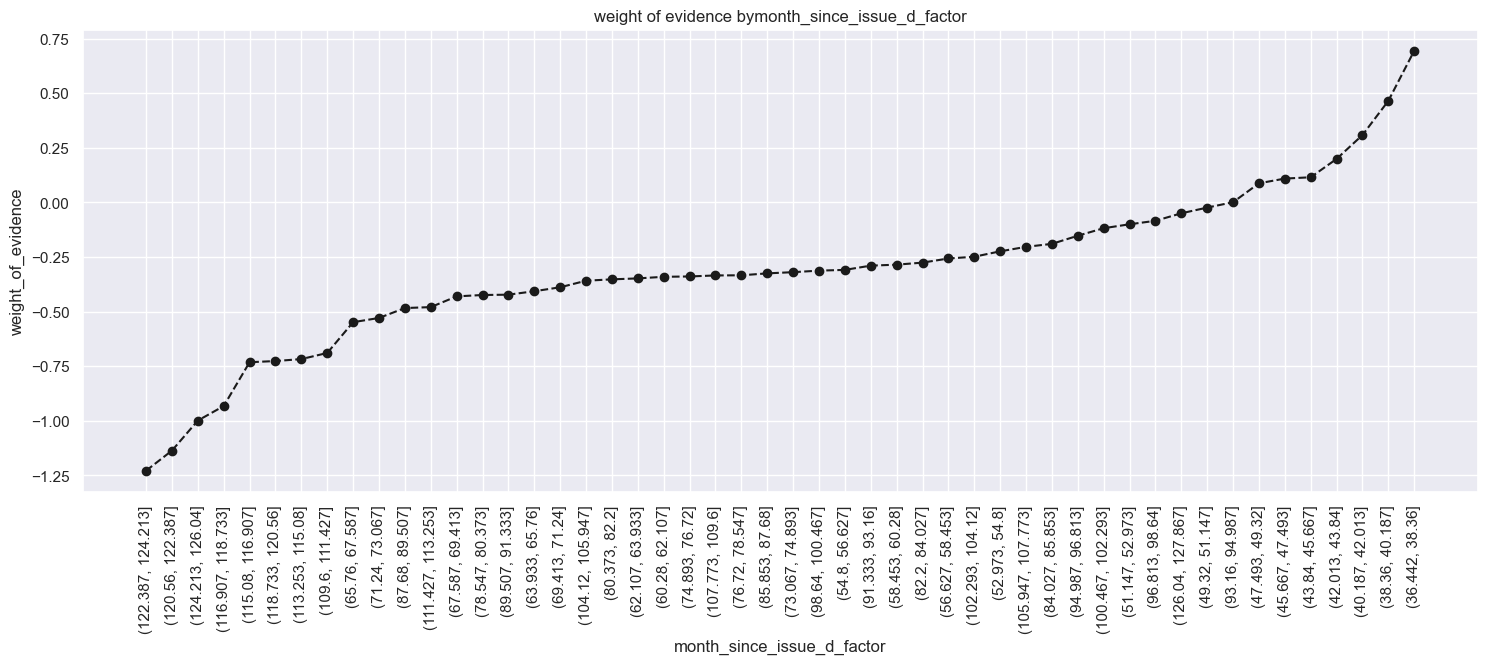

In [103]:

df_temp['sort_key']=df_temp['month_since_issue_d_factor'].apply(lambda x:x.left)
plot_by_woe(df_temp.sort_values(by='sort_key',ascending=True),90)   

In [104]:
df_inputs_prepr['month_since_issue_d'].unique()

array([ 45.7       ,  64.93333333,  54.8       ,  44.66666667,
       102.5       ,  37.53333333,  92.36666667,  53.8       ,
        42.63333333,  57.86666667,  58.8       ,  43.66666667,
        40.6       ,  51.73333333,  59.83333333, 114.66666667,
        50.73333333,  62.9       ,  49.7       ,  47.66666667,
        48.7       ,  41.63333333,  38.56666667,  66.96666667,
        70.03333333,  88.26666667,  46.63333333,  77.13333333,
        63.9       ,  39.56666667,  61.86666667,  90.33333333,
        65.96666667,  56.83333333,  80.2       ,  69.        ,
        52.76666667,  60.86666667,  74.06666667,  75.1       ,
        71.        ,  89.3       ,  82.23333333,  83.16666667,
        55.83333333, 104.53333333,  84.2       ,  73.06666667,
        86.23333333,  36.53333333,  72.03333333,  93.36666667,
        78.16666667,  68.        ,  85.23333333,  87.26666667,
        91.33333333, 117.7       ,  94.4       ,  96.36666667,
        79.16666667,  76.1       ,  81.2       ,  97.4 

In [105]:
df_inputs_prepr['month_since_issue_d:<38']=np.where(df_inputs_prepr['month_since_issue_d'].isin(range(38)),1,0)
df_inputs_prepr['month_since_issue_d:38-39']=np.where(df_inputs_prepr['month_since_issue_d'].isin(range(38,40)),1,0)
df_inputs_prepr['month_since_issue_d:40-41']=np.where(df_inputs_prepr['month_since_issue_d'].isin(range(40,42)),1,0)
df_inputs_prepr['month_since_issue_d:42-48']=np.where(df_inputs_prepr['month_since_issue_d'].isin(range(42,49)),1,0)
df_inputs_prepr['month_since_issue_d:49-52']=np.where(df_inputs_prepr['month_since_issue_d'].isin(range(49,53)),1,0)
df_inputs_prepr['month_since_issue_d:53-64']=np.where(df_inputs_prepr['month_since_issue_d'].isin(range(53,65)),1,0)
df_inputs_prepr['month_since_issue_d:65-84']=np.where(df_inputs_prepr['month_since_issue_d'].isin(range(65,85)),1,0)
df_inputs_prepr['month_since_issue_d:>85']=np.where(df_inputs_prepr['month_since_issue_d'].isin(range(85, int(df_inputs_prepr['month_since_issue_d'].max()))),1,0)

In [106]:
df_inputs_prepr['int_rate_factor']=pd.cut(df_inputs_prepr['int_rate'],50)

In [107]:
df_temp=woe_ordered_continuous(df_inputs_prepr,'int_rate_factor',df_targets_prepr)
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].mean()],axis=1)


,int_rate_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(5.399, 5.833]",785,0.961783,0.002104,0.038217,755.0,30.0,0.002272,0.000736,1.127775,0.001733
1,"(5.833, 6.246]",8459,0.980376,0.022677,0.019624,8293.0,166.0,0.024960,0.004071,1.813434,0.037881
2,"(6.246, 6.658]",7826,0.971505,0.020980,0.028495,7603.0,223.0,0.022883,0.005469,1.431381,0.024927
3,"(6.658, 7.071]",1816,0.973018,0.004868,0.026982,1767.0,49.0,0.005318,0.001202,1.487473,0.006123
4,"(7.071, 7.484]",3143,0.976456,0.008426,0.023544,3069.0,74.0,0.009237,0.001815,1.627297,0.012078
5,"(7.484, 7.897]",12581,0.962324,0.033727,0.037676,12107.0,474.0,0.036439,0.011624,1.142587,0.028354
6,"(7.897, 8.31]",9687,0.949314,0.025969,0.050686,9196.0,491.0,0.027678,0.012041,0.832335,0.013015
7,"(8.31, 8.722]",6594,0.965271,0.017677,0.034729,6365.0,229.0,0.019157,0.005616,1.227103,0.016617
8,"(8.722, 9.135]",9539,0.937415,0.025572,0.062585,8942.0,597.0,0.026913,0.014640,0.608852,0.007473
9,"(9.135, 9.548]",6681,0.963928,0.017910,0.036072,6440.0,241.0,0.019383,0.005910,1.187742,0.016002


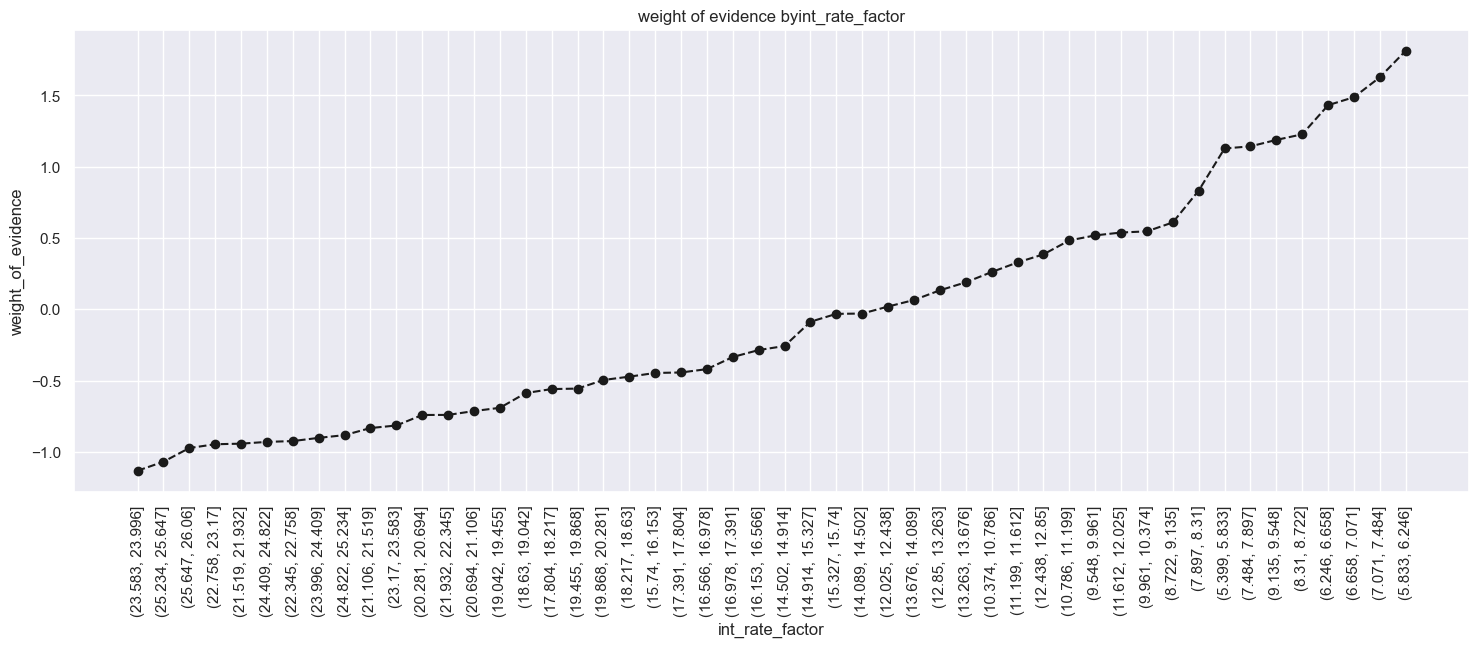

In [108]:
plot_by_woe(df_temp,90)

In [109]:
df_inputs_prepr['int_rate:<9.548']=np.where((df_inputs_prepr['int_rate']<=9.548),1,0)
df_inputs_prepr['int_rate:9.548-12.025']=np.where((df_inputs_prepr['int_rate']>9.548)&(df_inputs_prepr['int_rate']<12.025),1,0)
df_inputs_prepr['int_rate:12.025-15.74'] = np.where((df_inputs_prepr['int_rate'] > 12.025) & (df_inputs_prepr['int_rate'] <= 15.74), 1, 0)
df_inputs_prepr['int_rate:15.74-20.281']=np.where((df_inputs_prepr['int_rate']>15.74)&(df_inputs_prepr['int_rate']<20.281),1,0)
df_inputs_prepr['int_rate:>20.281']=np.where((df_inputs_prepr['int_rate']>20.281),1,0)

In [110]:
df_inputs_prepr['funded_amnt_factor']=pd.cut(df_inputs_prepr['funded_amnt'],50)
df_temp=woe_ordered_continuous(df_inputs_prepr,'funded_amnt_factor',df_targets_prepr)
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].mean()],axis=1)


,funded_amnt_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(465.5, 1190.0]",1224,0.905229,0.003281,0.094771,1108.0,116.0,0.003335,0.002845,0.158977,7.792514e-05
1,"(1190.0, 1880.0]",3028,0.903897,0.008117,0.096103,2737.0,291.0,0.008238,0.007136,0.143549,1.581301e-04
2,"(1880.0, 2570.0]",6018,0.893819,0.016133,0.106181,5379.0,639.0,0.016190,0.015670,0.032608,1.693683e-05
3,"(2570.0, 3260.0]",7248,0.889073,0.019430,0.110927,6444.0,804.0,0.019395,0.019717,-0.016440,5.284970e-06
4,"(3260.0, 3950.0]",4751,0.891602,0.012736,0.108398,4236.0,515.0,0.012749,0.012629,0.009463,1.136265e-06
5,"(3950.0, 4640.0]",9023,0.890945,0.024189,0.109055,8039.0,984.0,0.024196,0.024131,0.002689,1.747301e-07
6,"(4640.0, 5330.0]",15903,0.892159,0.042632,0.107841,14188.0,1715.0,0.042703,0.042057,0.015238,9.840896e-06
7,"(5330.0, 6020.0]",17236,0.906069,0.046206,0.093931,15617.0,1619.0,0.047004,0.039703,0.168806,1.232452e-03
8,"(6020.0, 6710.0]",6914,0.887619,0.018535,0.112381,6137.0,777.0,0.018471,0.019054,-0.031094,1.813905e-05
9,"(6710.0, 7400.0]",11806,0.898018,0.031649,0.101982,10602.0,1204.0,0.031910,0.029526,0.077648,1.851122e-04


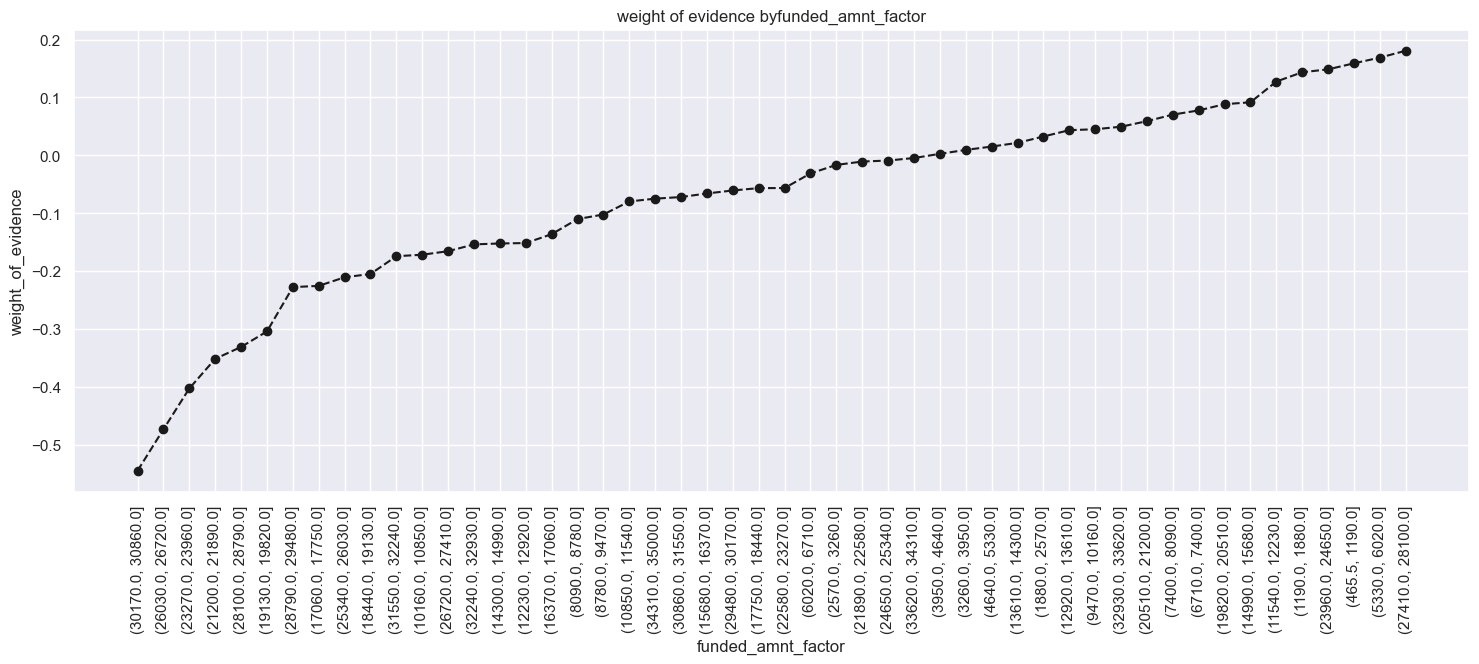

In [111]:
plot_by_woe(df_temp,90)

In [112]:
annual_inc_capped=df_inputs_prepr['annual_inc'].clip(upper=140000)

In [113]:
df_inputs_prepr['annual_inc_factor']=pd.cut(annual_inc_capped,50)

In [114]:
df_temp=woe_ordered_continuous(df_inputs_prepr,'annual_inc_factor',df_targets_prepr)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].mean()],axis=1)


In [115]:
df_temp

,annual_inc_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(1757.896, 4658.08]",15,0.800000,0.000040,0.200000,12.0,3.0,0.000036,0.000074,-0.711451,0.000027
1,"(4658.08, 7420.16]",40,0.750000,0.000107,0.250000,30.0,10.0,0.000090,0.000245,-0.999133,0.000155
2,"(7420.16, 10182.24]",287,0.874564,0.000769,0.125436,251.0,36.0,0.000755,0.000883,-0.155811,0.000020
3,"(10182.24, 12944.32]",547,0.828154,0.001466,0.171846,453.0,94.0,0.001363,0.002305,-0.525148,0.000495
4,"(12944.32, 15706.4]",1210,0.830579,0.003244,0.169421,1005.0,205.0,0.003025,0.005027,-0.508012,0.001017
5,"(15706.4, 18468.48]",1522,0.847569,0.004080,0.152431,1290.0,232.0,0.003883,0.005689,-0.382085,0.000690
6,"(18468.48, 21230.56]",2928,0.855533,0.007849,0.144467,2505.0,423.0,0.007540,0.010373,-0.319073,0.000904
7,"(21230.56, 23992.64]",2495,0.844489,0.006689,0.155511,2107.0,388.0,0.006342,0.009515,-0.405730,0.001288
8,"(23992.64, 26754.72]",7016,0.848632,0.018808,0.151368,5954.0,1062.0,0.017920,0.026043,-0.373836,0.003037
9,"(26754.72, 29516.8]",5643,0.857345,0.015128,0.142655,4838.0,805.0,0.014561,0.019741,-0.304331,0.001576


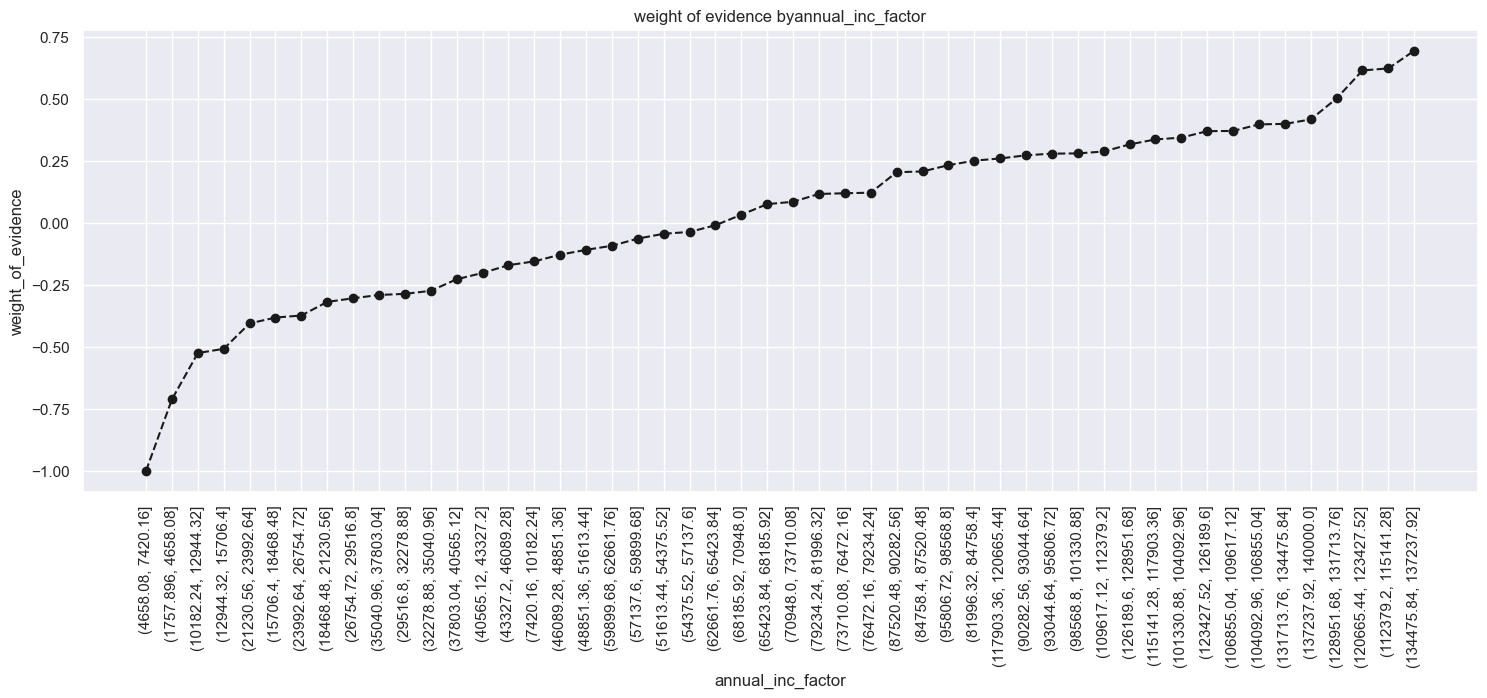

In [116]:
plot_by_woe(df_temp,90)

In [117]:
df_inputs_prepr['annual_inc:<20k']=np.where((df_inputs_prepr['annual_inc']<=20000),1,0)
df_inputs_prepr['annual_inc:20k-30k']=np.where((df_inputs_prepr['annual_inc']>20000)&(df_inputs_prepr['annual_inc']<=30000),1,0)
df_inputs_prepr['annual_inc:30k-40k']=np.where((df_inputs_prepr['annual_inc']>30000)&(df_inputs_prepr['annual_inc']<=40000),1,0)
df_inputs_prepr['annual_inc:40k-50k']=np.where((df_inputs_prepr['annual_inc']>40000)&(df_inputs_prepr['annual_inc']<=50000),1,0)
df_inputs_prepr['annual_inc:50k-60k']=np.where((df_inputs_prepr['annual_inc']>50000)&(df_inputs_prepr['annual_inc']<=60000),1,0)
df_inputs_prepr['annual_inc:60k-70k']=np.where((df_inputs_prepr['annual_inc']>60000)&(df_inputs_prepr['annual_inc']<=70000),1,0)
df_inputs_prepr['annual_inc:70k-80k']=np.where((df_inputs_prepr['annual_inc']>70000)&(df_inputs_prepr['annual_inc']<=80000),1,0)
df_inputs_prepr['annual_inc:80k-90k']=np.where((df_inputs_prepr['annual_inc']>80000)&(df_inputs_prepr['annual_inc']<=90000),1,0)
df_inputs_prepr['annual_inc:90k-100k']=np.where((df_inputs_prepr['annual_inc']>90000)&(df_inputs_prepr['annual_inc']<=100000),1,0)
df_inputs_prepr['annual_inc:100k-120k']=np.where((df_inputs_prepr['annual_inc']>100000)&(df_inputs_prepr['annual_inc']<=120000),1,0)
df_inputs_prepr['annual_inc:120k-140k']=np.where((df_inputs_prepr['annual_inc']>120000)&(df_inputs_prepr['annual_inc']<=140000),1,0)
df_inputs_prepr['annual_inc:>140k']=np.where((df_inputs_prepr['annual_inc']>140000),1,0)

In [118]:
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_delinq'])]
df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_delinq_factor', df_targets_prepr.loc[df_inputs_prepr_temp.index])
df_temp
                               

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3006549709.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and 

,mths_since_last_delinq_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(-0.188, 3.76]",5277,0.871518,0.030531,0.128482,4599.0,678.0,0.029814,0.036481,-0.201825,1.345636e-03
1,"(3.76, 7.52]",11167,0.887615,0.064608,0.112385,9912.0,1255.0,0.064256,0.067528,-0.049661,1.624709e-04
2,"(7.52, 11.28]",13306,0.892830,0.076983,0.107170,11880.0,1426.0,0.077014,0.076729,0.003711,1.058786e-06
3,"(11.28, 15.04]",13216,0.888847,0.076462,0.111153,11747.0,1469.0,0.076152,0.079042,-0.037256,1.076913e-04
4,"(15.04, 18.8]",9337,0.894934,0.054020,0.105066,8356.0,981.0,0.054169,0.052785,0.025891,3.584565e-05
5,"(18.8, 22.56]",11641,0.892707,0.067350,0.107293,10392.0,1249.0,0.067368,0.067205,0.002421,3.944869e-07
6,"(22.56, 26.32]",10887,0.896298,0.062988,0.103702,9758.0,1129.0,0.063258,0.060748,0.040483,1.016031e-04
7,"(26.32, 30.08]",10560,0.895076,0.061096,0.104924,9452.0,1108.0,0.061274,0.059618,0.027398,4.537112e-05
8,"(30.08, 33.84]",7576,0.902191,0.043832,0.097809,6835.0,741.0,0.044309,0.039871,0.105539,4.683861e-04
9,"(33.84, 37.6]",9795,0.897397,0.056670,0.102603,8790.0,1005.0,0.056982,0.054076,0.052355,1.521758e-04


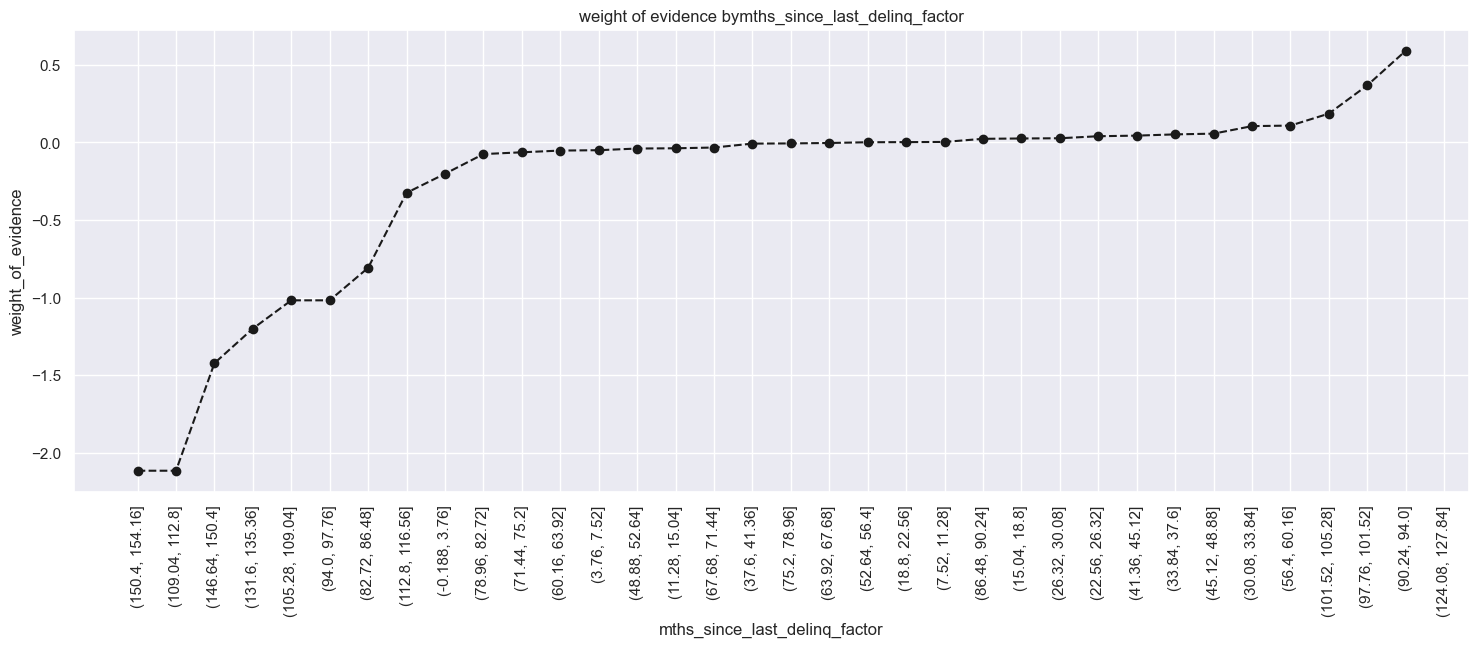

In [119]:
plot_by_woe(df_temp,90)

In [120]:

df_inputs_prepr['mths_since_last_delinq:Missing']=np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()),1,0)
df_inputs_prepr['mths_since_last_delinq:0-3']=np.where((df_inputs_prepr['mths_since_last_delinq']>=0)&(df_inputs_prepr['mths_since_last_delinq']<=3),1,0)
df_inputs_prepr['mths_since_last_delinq:4-30']=np.where((df_inputs_prepr['mths_since_last_delinq']>=4)&(df_inputs_prepr['mths_since_last_delinq']<=30),1,0)
df_inputs_prepr['mths_since_last_delinq:31-56']=np.where((df_inputs_prepr['mths_since_last_delinq']>=31)&(df_inputs_prepr['mths_since_last_delinq']<=56),1,0)
df_inputs_prepr['mths_since_last_delinq:>=57']=np.where((df_inputs_prepr['mths_since_last_delinq']>=57),1,0)


In [121]:
df_temp = woe_discrete(df_inputs_prepr, 'verification_status', df_targets_prepr)
df_temp

,verification_status,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,Not Verified,118584,0.905679,0.317896,0.094321,107399.0,11185.0,0.323248,0.274290,0.164232,0.008040
1,Source Verified,120030,0.895918,0.321772,0.104082,107537.0,12493.0,0.323663,0.306366,0.054922,0.000950
2,Verified,134414,0.872781,0.360332,0.127219,117314.0,17100.0,0.353090,0.419344,-0.171969,0.011394


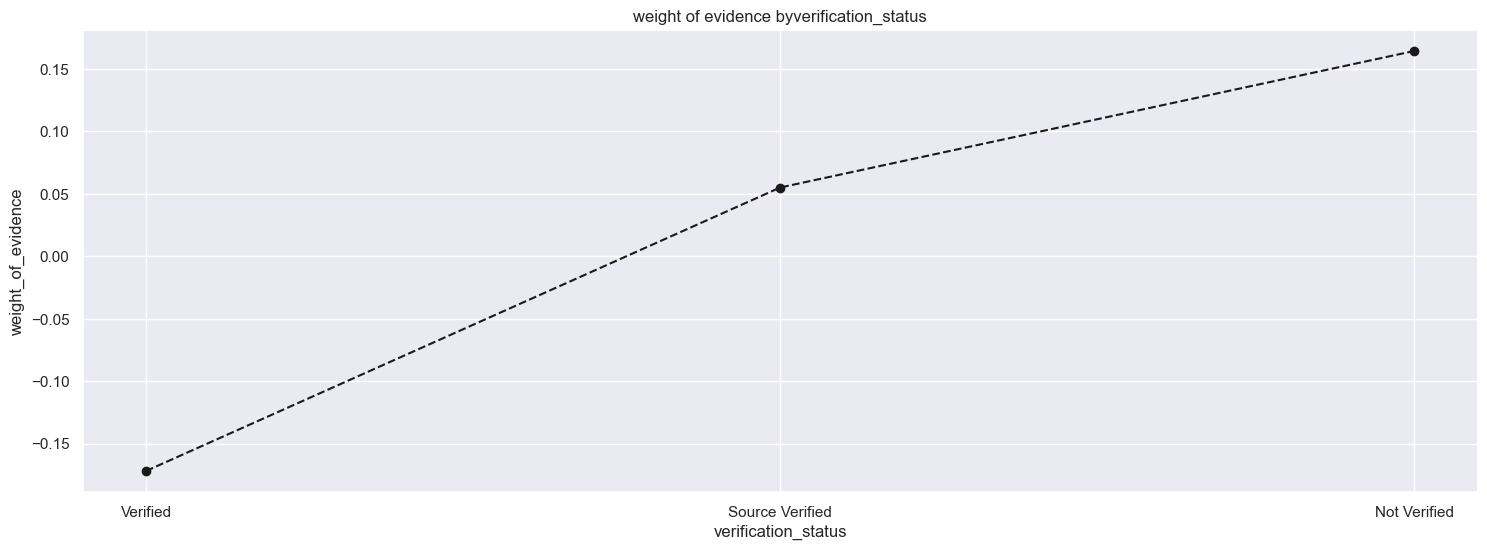

In [122]:
plot_by_woe(df_temp)

In [123]:
df_temp = woe_discrete(df_inputs_prepr, 'purpose', df_targets_prepr)
df_temp

,purpose,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,car,4325,0.909595,0.011594,0.090405,3934.0,391.0,0.011840,0.009589,0.210959,0.000475
1,credit_card,83581,0.913102,0.224061,0.086898,76318.0,7263.0,0.229701,0.178111,0.254371,0.013123
2,debt_consolidation,219183,0.886884,0.587578,0.113116,194390.0,24793.0,0.585071,0.607999,-0.038440,0.000881
3,educational,333,0.801802,0.000893,0.198198,267.0,66.0,0.000804,0.001619,-0.700151,0.000571
4,home_improvement,21238,0.900697,0.056934,0.099303,19129.0,2109.0,0.057574,0.051719,0.107247,0.000628
5,house,1830,0.860109,0.004906,0.139891,1574.0,256.0,0.004737,0.006278,-0.281547,0.000434
6,major_purchase,7837,0.905449,0.021009,0.094551,7096.0,741.0,0.021357,0.018172,0.161541,0.000515
7,medical,3684,0.868350,0.009876,0.131650,3199.0,485.0,0.009628,0.011894,-0.211300,0.000479
8,moving,2392,0.839465,0.006412,0.160535,2008.0,384.0,0.006044,0.009417,-0.443493,0.001496
9,other,18884,0.862264,0.050624,0.137736,16283.0,2601.0,0.049008,0.063784,-0.263519,0.003894


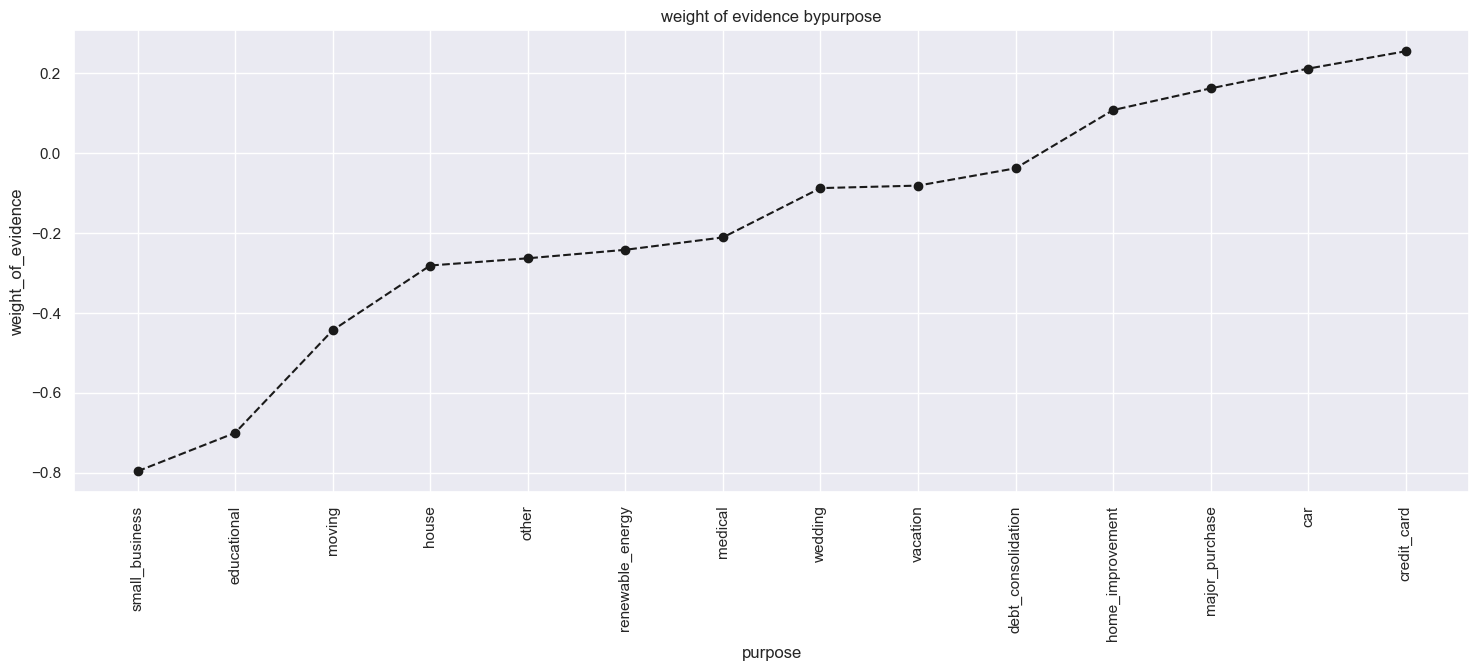

In [124]:
plot_by_woe(df_temp, 90)

In [125]:
df_inputs_prepr['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([df_inputs_prepr['purpose:educational'], df_inputs_prepr['purpose:small_business'],
                                                                 df_inputs_prepr['purpose:wedding'], df_inputs_prepr['purpose:renewable_energy'],
                                                                 df_inputs_prepr['purpose:moving'], df_inputs_prepr['purpose:house']])
df_inputs_prepr['purpose:oth__med__vacation'] = sum([df_inputs_prepr['purpose:other'], df_inputs_prepr['purpose:medical'],
                                             df_inputs_prepr['purpose:vacation']])
df_inputs_prepr['purpose:major_purch__car__home_impr'] = sum([df_inputs_prepr['purpose:major_purchase'], df_inputs_prepr['purpose:car'],
                                                        df_inputs_prepr['purpose:home_improvement']])

In [126]:
df_temp = woe_discrete(df_inputs_prepr, 'initial_list_status', df_targets_prepr)
df_temp

,initial_list_status,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,f,242514,0.879694,0.650123,0.120306,213338.0,29176.0,0.642101,0.715484,-0.108214,0.007941
1,w,130514,0.911105,0.349877,0.088895,118912.0,11602.0,0.357899,0.284516,0.229461,0.016839


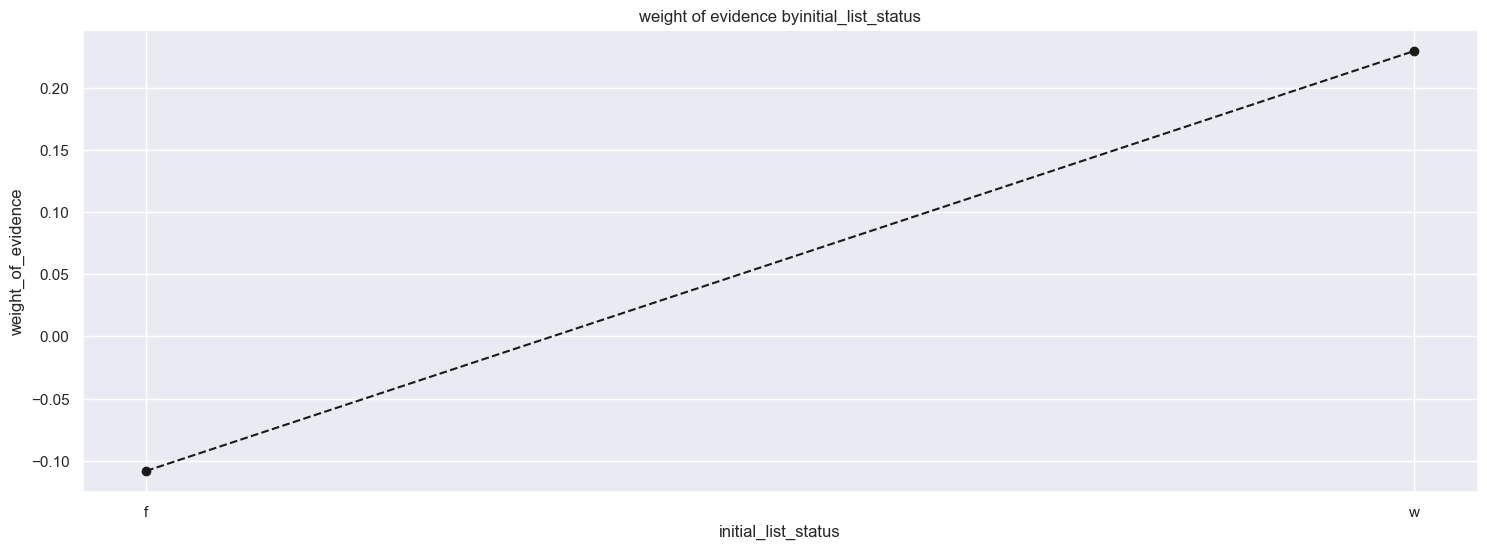

In [127]:
plot_by_woe(df_temp)

In [128]:
df_inputs_prepr['month_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr['month_since_earliest_cr_line'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'month_since_earliest_cr_line_factor', df_targets_prepr)
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].mean()],axis=1)


,month_since_earliest_cr_line_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(73.478, 84.44]",849,0.898704,0.002276,0.101296,763.0,86.0,0.002297,0.002109,0.085155,1.596435e-05
1,"(84.44, 94.88]",1802,0.884018,0.004831,0.115982,1593.0,209.0,0.004795,0.005126,-0.066715,2.206970e-05
2,"(94.88, 105.32]",2384,0.856544,0.006391,0.143456,2042.0,342.0,0.006146,0.008387,-0.310881,6.967247e-04
3,"(105.32, 115.76]",3504,0.874429,0.009394,0.125571,3064.0,440.0,0.009223,0.010791,-0.157054,2.463183e-04
4,"(115.76, 126.2]",7197,0.864944,0.019295,0.135056,6225.0,972.0,0.018737,0.023838,-0.240782,1.228246e-03
5,"(126.2, 136.64]",8852,0.861274,0.023732,0.138726,7624.0,1228.0,0.022948,0.030116,-0.271841,1.948683e-03
6,"(136.64, 147.08]",12069,0.870246,0.032356,0.129754,10503.0,1566.0,0.031614,0.038406,-0.194619,1.321881e-03
7,"(147.08, 157.52]",11537,0.878478,0.030930,0.121522,10135.0,1402.0,0.030506,0.034384,-0.119660,4.640126e-04
8,"(157.52, 167.96]",14483,0.879445,0.038828,0.120555,12737.0,1746.0,0.038338,0.042820,-0.110572,4.956199e-04
9,"(167.96, 178.4]",16547,0.884632,0.044361,0.115368,14638.0,1909.0,0.044060,0.046818,-0.060714,1.674451e-04


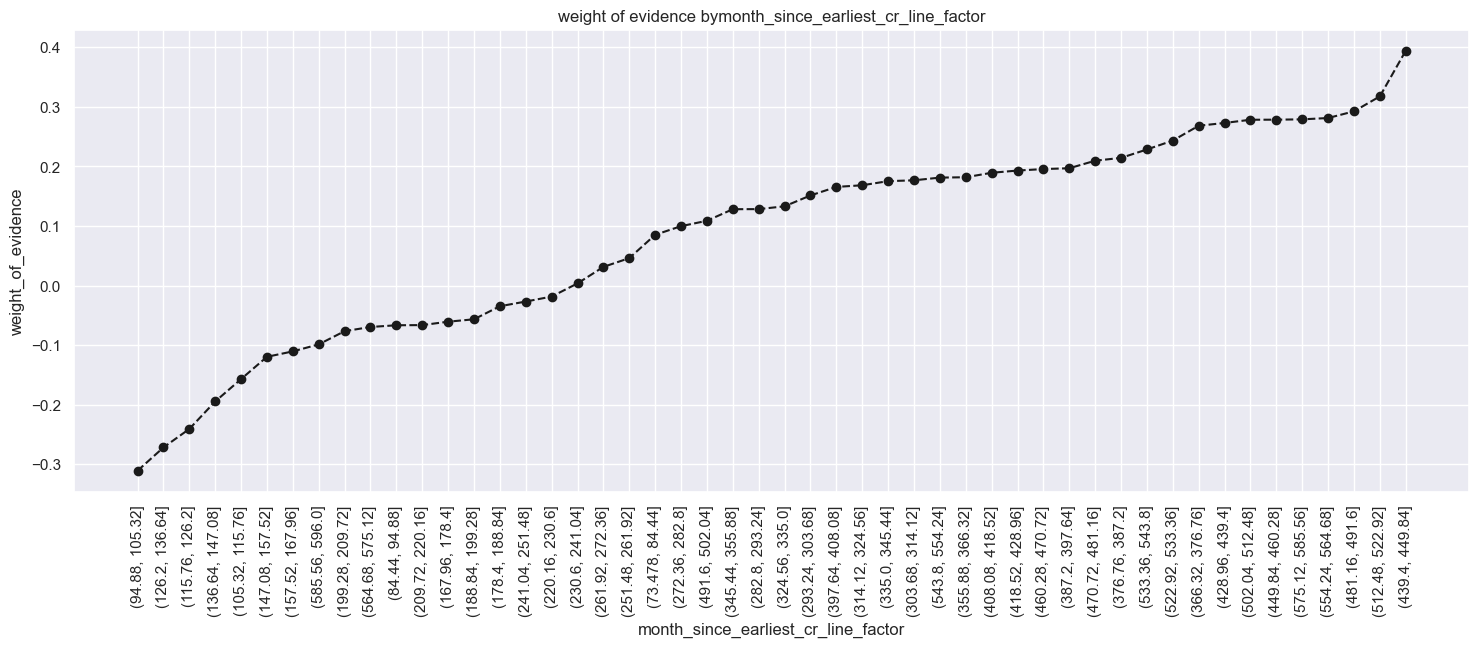

In [129]:
plot_by_woe(df_temp, 90)

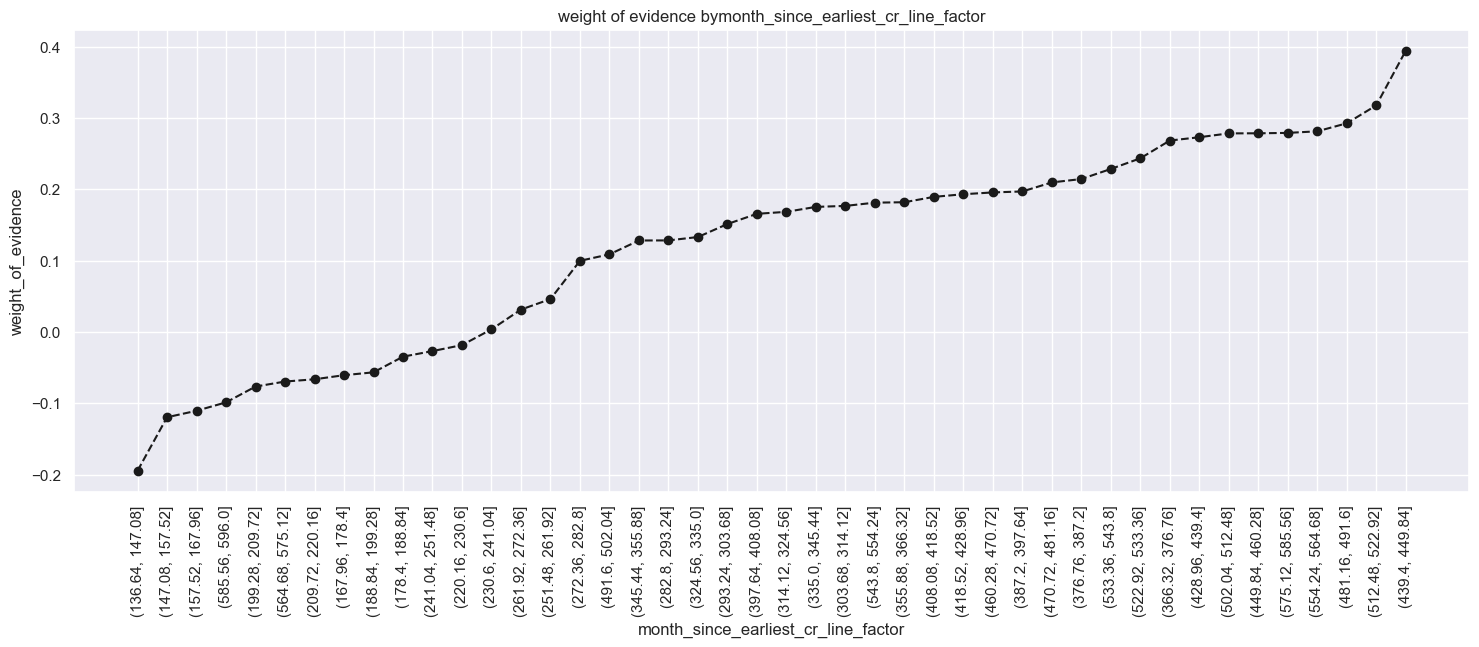

In [130]:
plot_by_woe(df_temp.iloc[6: , : ], 90)

In [131]:
df_inputs_prepr['month_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr['month_since_earliest_cr_line'].isin(range(140)), 1, 0)
df_inputs_prepr['month_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr['month_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)
df_inputs_prepr['month_since_earliest_cr_line:165-247'] = np.where(df_inputs_prepr['month_since_earliest_cr_line'].isin(range(165, 248)), 1, 0)
df_inputs_prepr['month_since_earliest_cr_line:248-270'] = np.where(df_inputs_prepr['month_since_earliest_cr_line'].isin(range(248, 271)), 1, 0)
df_inputs_prepr['month_since_earliest_cr_line:271-352'] = np.where(df_inputs_prepr['month_since_earliest_cr_line'].isin(range(271, 353)), 1, 0)
df_inputs_prepr['month_since_earliest_cr_line:>352'] = np.where(df_inputs_prepr['month_since_earliest_cr_line'].isin(range(353, int(df_inputs_prepr['month_since_earliest_cr_line'].max()))), 1, 0)

In [132]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'delinq_2yrs', df_targets_prepr)
df_temp

,delinq_2yrs,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,0.0,306393,0.890500,0.821367,0.109500,272843.0,33550.0,0.821198,0.822748,-0.001885,2.921591e-06
1,1.0,44927,0.893249,0.120439,0.106751,40131.0,4796.0,0.120786,0.117612,0.026622,8.447431e-05
2,2.0,13118,0.889007,0.035166,0.110993,11662.0,1456.0,0.035100,0.035706,-0.017102,1.035459e-05
3,3.0,4550,0.883297,0.012197,0.116703,4019.0,531.0,0.012096,0.013022,-0.073719,6.822026e-05
4,4.0,1868,0.898822,0.005008,0.101178,1679.0,189.0,0.005053,0.004635,0.086462,3.619039e-05
5,5.0,966,0.881988,0.002590,0.118012,852.0,114.0,0.002564,0.002796,-0.086357,1.997357e-05
6,6.0,501,0.902196,0.001343,0.097804,452.0,49.0,0.001360,0.001202,0.124117,1.970890e-05
7,7.0,279,0.860215,0.000748,0.139785,240.0,39.0,0.000722,0.000956,-0.280668,6.569040e-05
8,8.0,148,0.905405,0.000397,0.094595,134.0,14.0,0.000403,0.000343,0.161037,9.660378e-06
9,9.0,89,0.887640,0.000239,0.112360,79.0,10.0,0.000238,0.000245,-0.030882,2.303044e-07


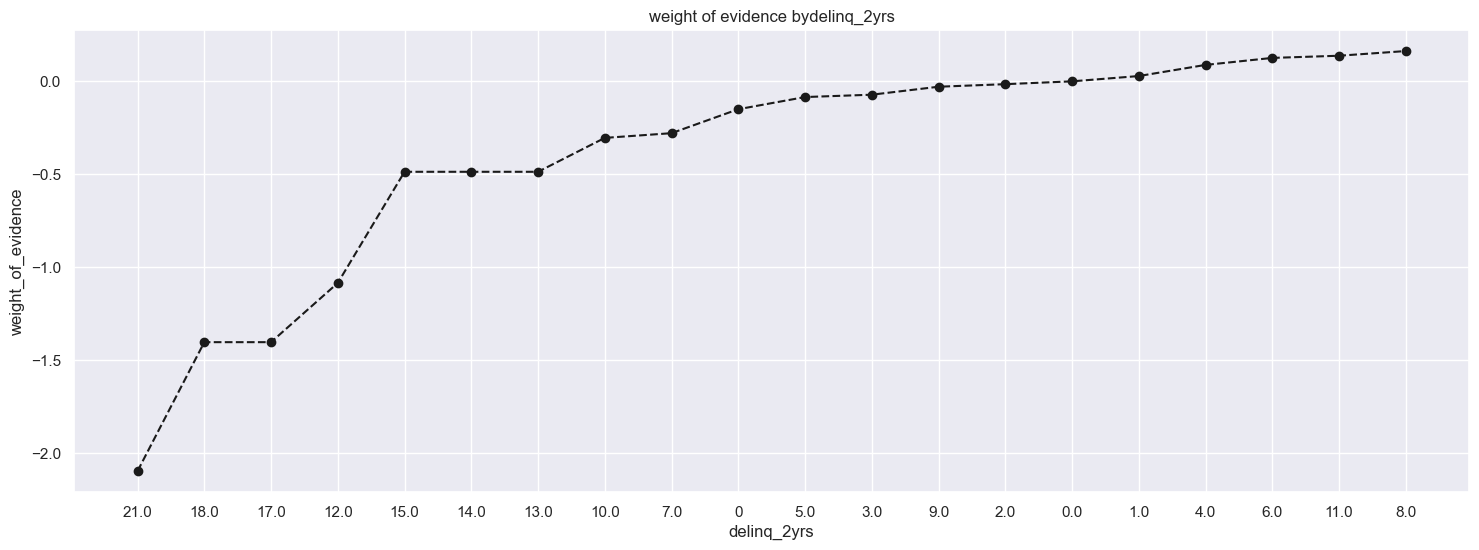

In [133]:
plot_by_woe(df_temp)

In [134]:
df_inputs_prepr['delinq_2yrs']=pd.to_numeric(df_inputs_prepr['delinq_2yrs'],errors='coerce')

In [135]:
df_inputs_prepr['delinq_2yrs:0'] = np.where((df_inputs_prepr['delinq_2yrs'] == 0), 1, 0)
df_inputs_prepr['delinq_2yrs:1-3'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 1) & (df_inputs_prepr['delinq_2yrs'] <= 3), 1, 0)
df_inputs_prepr['delinq_2yrs:>=4'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 4), 1, 0)

In [136]:
print(df_inputs_prepr['delinq_2yrs'].dtype)

float64


In [137]:
df_inputs_prepr['delinq_2yrs'].unique()

array([ 0.,  1.,  4.,  2.,  5.,  3.,  6.,  9.,  8.,  7., 11., 24., 10.,
       12., 18., 13., 14., 17., 19., 15., 16., 22., 21., 29.])

In [138]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'inq_last_6mths', df_targets_prepr)
df_temp

C:\Users\aswin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,inq_last_6mths,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,0.0,193208,0.908399,0.517945,0.091601,175510.0,17698.0,0.528247,0.434009,0.196499,1.851776e-02
1,1.0,104163,0.884950,0.279236,0.115050,92179.0,11984.0,0.277439,0.293884,-0.057585,9.470026e-04
2,2.0,46214,0.864197,0.123889,0.135803,39938.0,6276.0,0.120205,0.153907,-0.247150,8.329398e-03
3,3.0,20040,0.839671,0.053723,0.160329,16827.0,3213.0,0.050646,0.078792,-0.441965,1.243995e-02
4,4.0,5810,0.848365,0.015575,0.151635,4929.0,881.0,0.014835,0.021605,-0.375911,2.544758e-03
5,5.0,2217,0.824989,0.005943,0.175011,1829.0,388.0,0.005505,0.009515,-0.547226,2.194399e-03
6,6.0,977,0.788127,0.002619,0.211873,770.0,207.0,0.002318,0.005076,-0.784073,2.163050e-03
7,7.0,159,0.679245,0.000426,0.320755,108.0,51.0,0.000325,0.001251,-1.347439,1.247214e-03
8,8.0,101,0.643564,0.000271,0.356436,65.0,36.0,0.000196,0.000883,-1.506877,1.035515e-03
9,9.0,43,0.674419,0.000115,0.325581,29.0,14.0,0.000087,0.000343,-1.369506,3.506467e-04


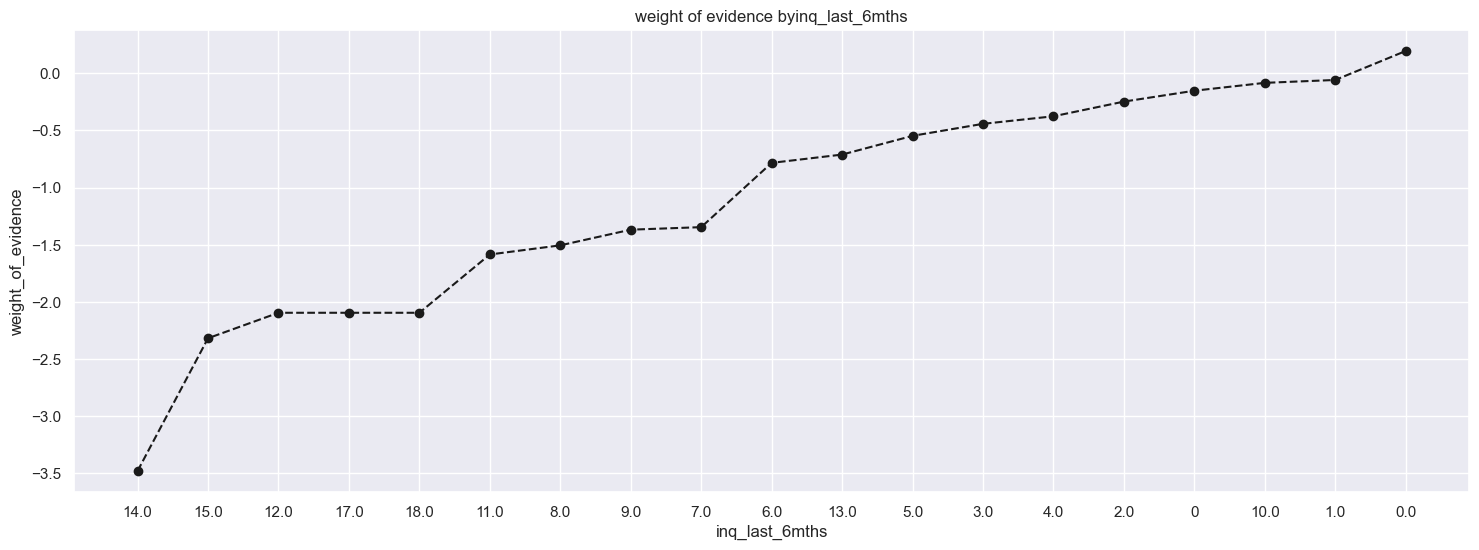

In [139]:
plot_by_woe(df_temp)

In [140]:
df_inputs_prepr['inq_last_6mths'] =pd.to_numeric(df_inputs_prepr['inq_last_6mths'],errors='coerce')

In [141]:
df_inputs_prepr['inq_last_6mths:0'] = np.where((df_inputs_prepr['inq_last_6mths'] == 0), 1, 0)
df_inputs_prepr['inq_last_6mths:1-2'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 1) & (df_inputs_prepr['inq_last_6mths'] <= 2), 1, 0)
df_inputs_prepr['inq_last_6mths:3-6'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 3) & (df_inputs_prepr['inq_last_6mths'] <= 6), 1, 0)
df_inputs_prepr['inq_last_6mths:>6'] = np.where((df_inputs_prepr['inq_last_6mths'] > 6), 1, 0)

In [142]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'open_acc', df_targets_prepr)
df_temp

C:\Users\aswin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,open_acc,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,0.0,5,0.200000,0.000013,0.800000,1.0,4.0,0.000003,0.000098,-3.484039,3.312706e-04
1,1.0,110,0.872727,0.000295,0.127273,96.0,14.0,0.000289,0.000343,-0.172454,9.378629e-06
2,2.0,1456,0.845467,0.003903,0.154533,1231.0,225.0,0.003705,0.005518,-0.398263,7.219078e-04
3,3.0,4378,0.873687,0.011736,0.126313,3825.0,553.0,0.011512,0.013561,-0.163789,3.355744e-04
4,4.0,10028,0.891504,0.026883,0.108496,8940.0,1088.0,0.026907,0.026681,0.008449,1.912922e-06
5,5.0,17141,0.891255,0.045951,0.108745,15277.0,1864.0,0.045980,0.045711,0.005879,1.584401e-06
6,6.0,24621,0.892368,0.066003,0.107632,21971.0,2650.0,0.066128,0.064986,0.017419,1.989040e-05
7,7.0,30169,0.891544,0.080876,0.108456,26897.0,3272.0,0.080954,0.080239,0.008868,6.338714e-06
8,8.0,33579,0.891033,0.090017,0.108967,29920.0,3659.0,0.090053,0.089730,0.003592,1.160004e-06
9,9.0,35251,0.889195,0.094500,0.110805,31345.0,3906.0,0.094342,0.095787,-0.015204,2.197492e-05


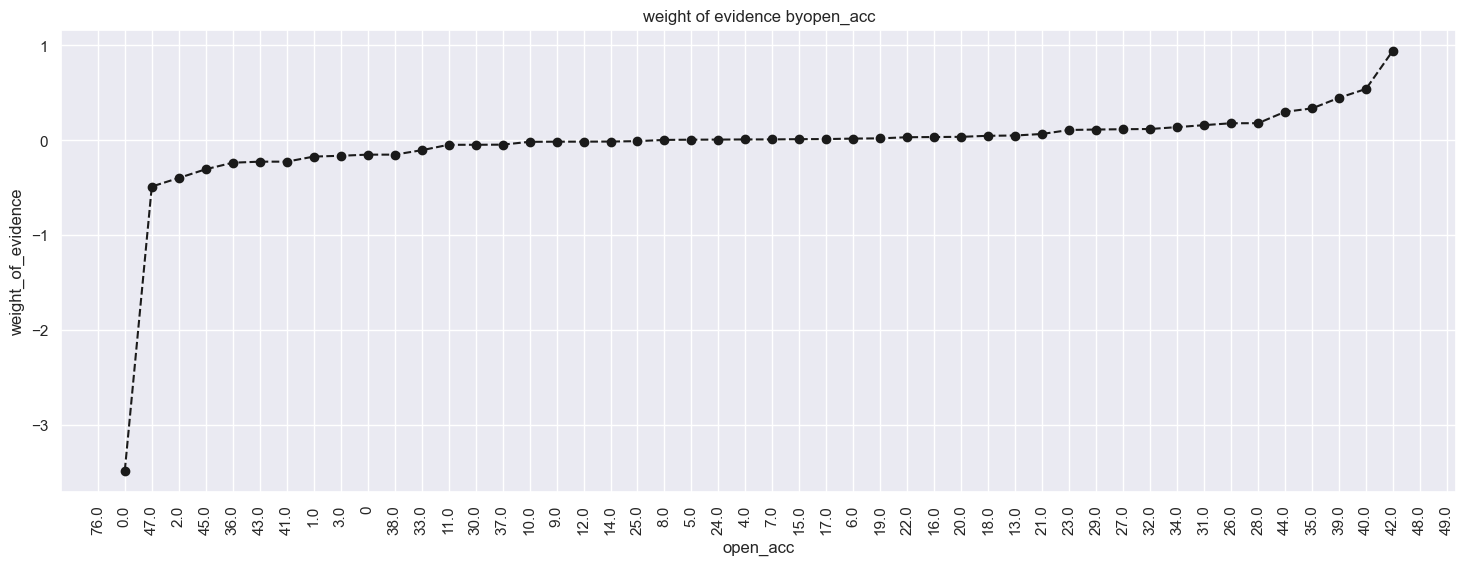

In [143]:
plot_by_woe(df_temp, 90)

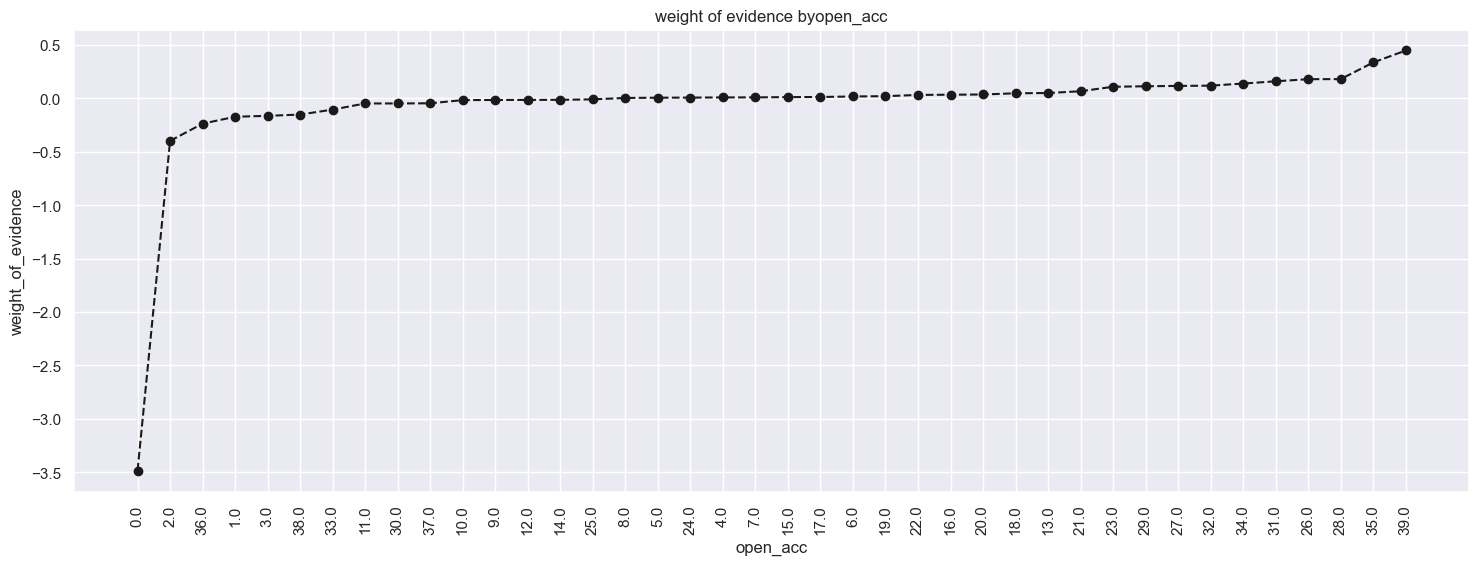

In [144]:
plot_by_woe(df_temp.iloc[ : 40, :], 90)

In [145]:
df_inputs_prepr['open_acc']=pd.to_numeric(df_inputs_prepr['open_acc'],errors='coerce')

In [146]:
df_inputs_prepr['open_acc:0'] = np.where((df_inputs_prepr['open_acc'] == 0), 1, 0)
df_inputs_prepr['open_acc:1-3'] = np.where((df_inputs_prepr['open_acc'] >= 1) & (df_inputs_prepr['open_acc'] <= 3), 1, 0)
df_inputs_prepr['open_acc:4-12'] = np.where((df_inputs_prepr['open_acc'] >= 4) & (df_inputs_prepr['open_acc'] <= 12), 1, 0)
df_inputs_prepr['open_acc:13-17'] = np.where((df_inputs_prepr['open_acc'] >= 13) & (df_inputs_prepr['open_acc'] <= 17), 1, 0)
df_inputs_prepr['open_acc:18-22'] = np.where((df_inputs_prepr['open_acc'] >= 18) & (df_inputs_prepr['open_acc'] <= 22), 1, 0)
df_inputs_prepr['open_acc:23-25'] = np.where((df_inputs_prepr['open_acc'] >= 23) & (df_inputs_prepr['open_acc'] <= 25), 1, 0)
df_inputs_prepr['open_acc:26-30'] = np.where((df_inputs_prepr['open_acc'] >= 26) & (df_inputs_prepr['open_acc'] <= 30), 1, 0)
df_inputs_prepr['open_acc:>=31'] = np.where((df_inputs_prepr['open_acc'] >= 31), 1, 0)

In [147]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'pub_rec', df_targets_prepr)
df_temp

,pub_rec,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,0.0,323975,0.889942,0.868500,0.110058,288319.0,35656.0,0.867777,0.874393,-0.007595,0.000050
1,1.0,42381,0.893419,0.113613,0.106581,37864.0,4517.0,0.113962,0.110771,0.028408,0.000091
2,2.0,4527,0.903247,0.012136,0.096753,4089.0,438.0,0.012307,0.010741,0.136092,0.000213
3,3.0,1280,0.920312,0.003431,0.079688,1178.0,102.0,0.003546,0.002501,0.348856,0.000364
4,4.0,408,0.924020,0.001094,0.075980,377.0,31.0,0.001135,0.000760,0.400513,0.000150
5,5.0,203,0.911330,0.000544,0.088670,185.0,18.0,0.000557,0.000441,0.232239,0.000027
6,6.0,117,0.931624,0.000314,0.068376,109.0,8.0,0.000328,0.000196,0.514161,0.000068
7,7.0,48,0.958333,0.000129,0.041667,46.0,2.0,0.000138,0.000049,1.037749,0.000093
8,8.0,24,1.000000,0.000064,0.000000,24.0,0.0,0.000072,0.000000,inf,inf
9,9.0,14,0.785714,0.000038,0.214286,11.0,3.0,0.000033,0.000074,-0.798462,0.000032


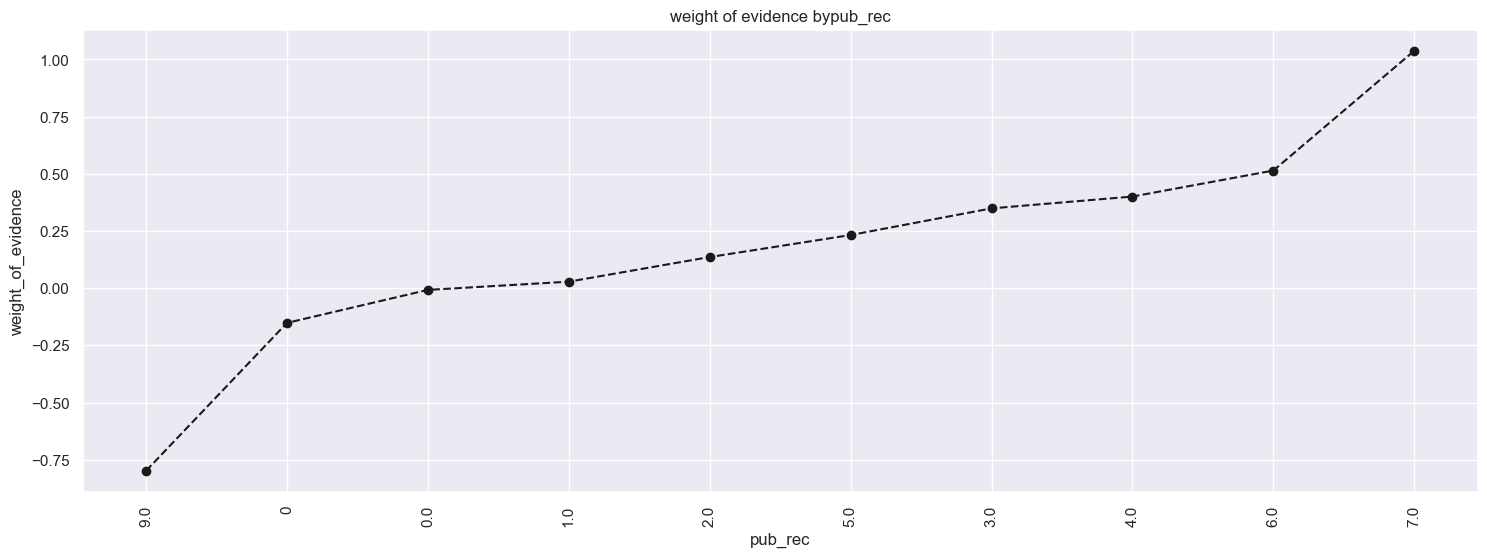

In [148]:
plot_by_woe(df_temp, 90)

In [149]:
df_inputs_prepr['pub_rec']=pd.to_numeric(df_inputs_prepr['pub_rec'],errors='coerce')

In [150]:
df_inputs_prepr['pub_rec:0-2'] = np.where((df_inputs_prepr['pub_rec'] >= 0) & (df_inputs_prepr['pub_rec'] <= 2), 1, 0)
df_inputs_prepr['pub_rec:3-4'] = np.where((df_inputs_prepr['pub_rec'] >= 3) & (df_inputs_prepr['pub_rec'] <= 4), 1, 0)
df_inputs_prepr['pub_rec:>=5'] = np.where((df_inputs_prepr['pub_rec'] >= 5), 1, 0)

In [151]:
df_inputs_prepr['total_acc']=pd.to_numeric(df_inputs_prepr['total_acc'],errors='coerce')

In [152]:
df_inputs_prepr['total_acc'].sum()

np.float64(9348510.0)

In [153]:
df_inputs_prepr['total_acc_factor'] = pd.cut(df_inputs_prepr['total_acc'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_acc_factor', df_targets_prepr)
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].mean()],axis=1)


,total_acc_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(-0.15, 3.0]",459,0.810458,0.001230,0.189542,372.0,87.0,0.001120,0.002134,-0.644759,6.536985e-04
1,"(3.0, 6.0]",6004,0.864757,0.016095,0.135243,5192.0,812.0,0.015627,0.019913,-0.242371,1.038781e-03
2,"(6.0, 9.0]",15047,0.873131,0.040337,0.126869,13138.0,1909.0,0.039543,0.046814,-0.168816,1.227619e-03
3,"(9.0, 12.0]",25169,0.881283,0.067472,0.118717,22181.0,2988.0,0.066760,0.073275,-0.093113,6.066170e-04
4,"(12.0, 15.0]",33651,0.881281,0.090210,0.118719,29656.0,3995.0,0.089258,0.097969,-0.093124,8.112416e-04
5,"(15.0, 18.0]",38711,0.887267,0.103775,0.112733,34347.0,4364.0,0.103377,0.107018,-0.034619,1.260669e-04
6,"(18.0, 21.0]",40599,0.886155,0.108836,0.113845,35977.0,4622.0,0.108283,0.113345,-0.045693,2.313196e-04
7,"(21.0, 24.0]",40163,0.891492,0.107668,0.108508,35805.0,4358.0,0.107765,0.106871,0.008329,7.445466e-06
8,"(24.0, 27.0]",36286,0.895442,0.097274,0.104558,32492.0,3794.0,0.097794,0.093040,0.049828,2.368559e-04
9,"(27.0, 30.0]",31775,0.899103,0.085181,0.100897,28569.0,3206.0,0.085986,0.078621,0.089553,6.596157e-04


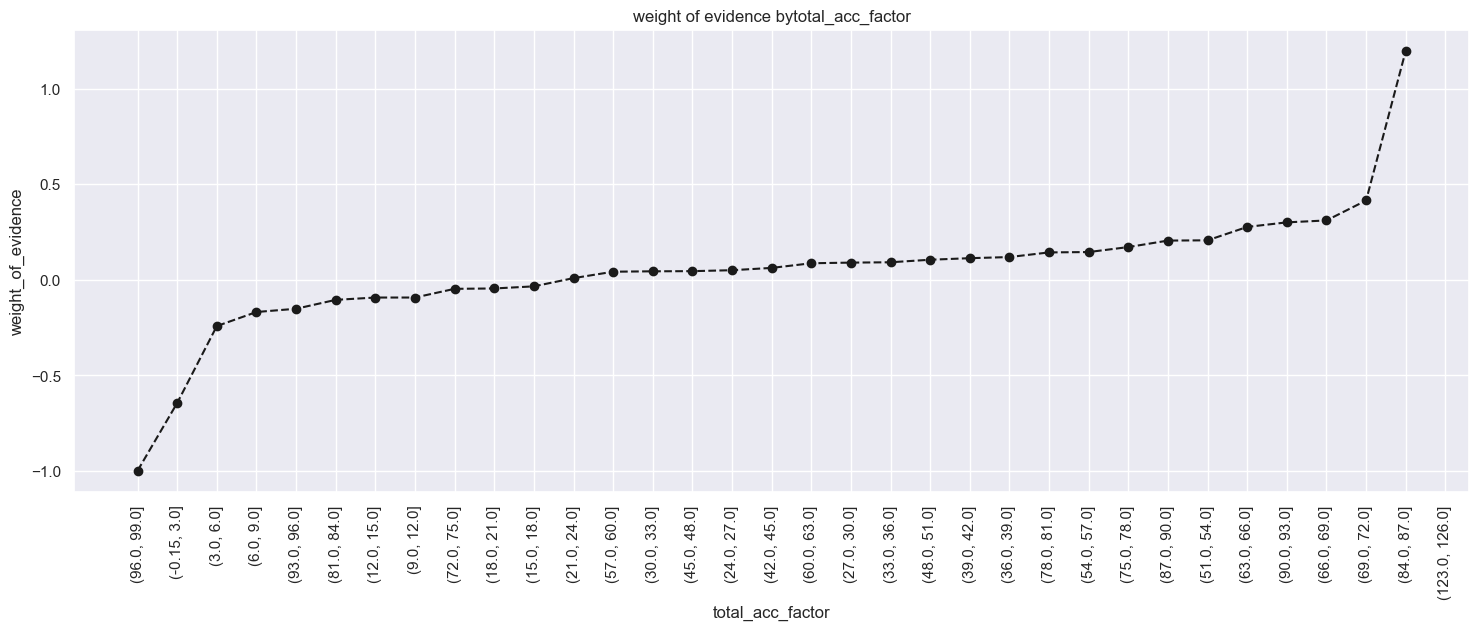

In [154]:
plot_by_woe(df_temp, 90)

In [155]:
df_inputs_prepr['total_acc:<=27'] = np.where((df_inputs_prepr['total_acc'] <= 27), 1, 0)
df_inputs_prepr['total_acc:28-51'] = np.where((df_inputs_prepr['total_acc'] >= 28) & (df_inputs_prepr['total_acc'] <= 51), 1, 0)
df_inputs_prepr['total_acc:>=52'] = np.where((df_inputs_prepr['total_acc'] >= 52), 1, 0)

In [156]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'acc_now_delinq', df_targets_prepr)
df_temp

,acc_now_delinq,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,0.0,371658,0.890649,0.996327,0.109351,331017.0,40641.0,0.996289,0.996640,-0.000353,1.239245e-07
1,1.0,1263,0.899446,0.003386,0.100554,1136.0,127.0,0.003419,0.003114,0.093337,2.843849e-05
2,2.0,70,0.928571,0.000188,0.071429,65.0,5.0,0.000196,0.000123,0.467204,3.411558e-05
3,3.0,7,0.857143,0.000019,0.142857,6.0,1.0,0.000018,0.000025,-0.305986,1.977993e-06
4,4.0,4,1.000000,0.000011,0.000000,4.0,0.0,0.000012,0.000000,inf,inf
5,5.0,2,0.500000,0.000005,0.500000,1.0,1.0,0.000003,0.000025,-2.097745,4.512930e-05
6,0,24,0.875000,0.000064,0.125000,21.0,3.0,0.000063,0.000074,-0.151835,1.573565e-06


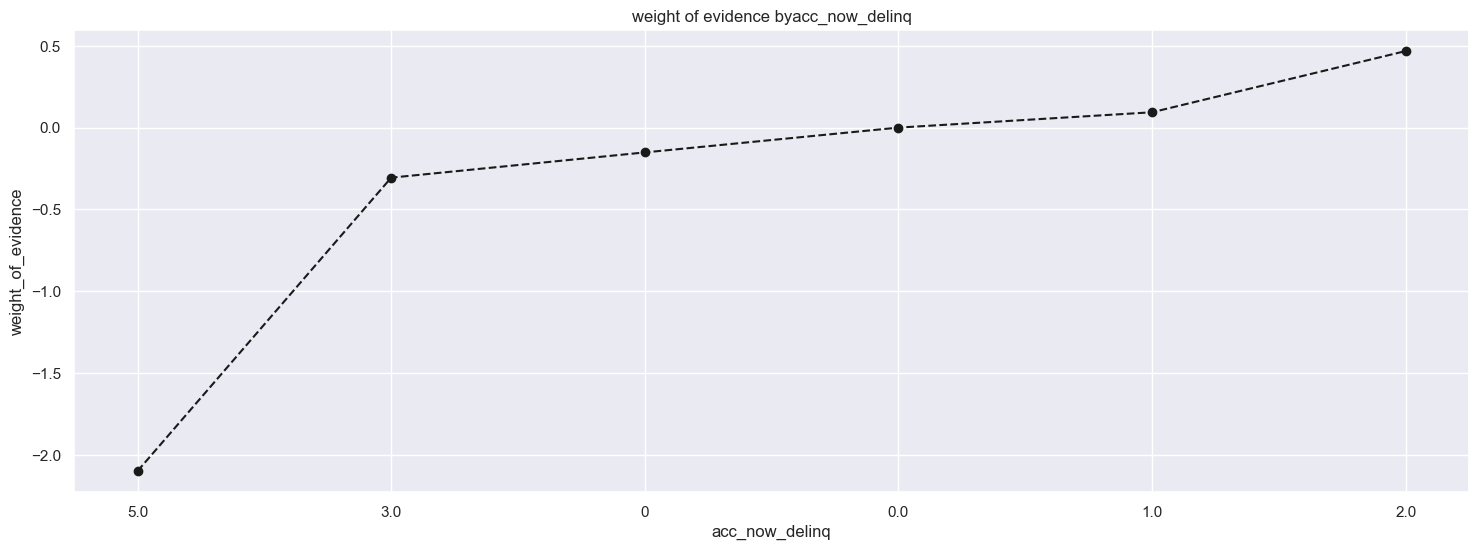

In [157]:
plot_by_woe(df_temp)

In [158]:
df_inputs_prepr['acc_now_delinq']=pd.to_numeric(df_inputs_prepr['acc_now_delinq'],errors='coerce')

In [159]:
df_inputs_prepr['acc_now_delinq:0'] = np.where((df_inputs_prepr['acc_now_delinq'] == 0), 1, 0)
df_inputs_prepr['acc_now_delinq:>=1'] = np.where((df_inputs_prepr['acc_now_delinq'] >= 1), 1, 0)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\2134325986.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['acc_now_delinq:0'] = np.where((df_inputs_prepr['acc_now_delinq'] == 0), 1, 0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\2134325986.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['acc_now_delinq:>=1'] = np.where((df_inputs_prepr['acc_now_delinq'] >= 1), 1, 0)


In [160]:
df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr['total_rev_hi_lim'], 2000)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_rev_hi_lim_factor', df_targets_prepr)
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\1019503949.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr['total_rev_hi_lim'], 2000)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a fu

,total_rev_hi_lim_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(-9999.999, 5000.0]",19417,0.866457,0.052052,0.133543,16824.0,2593.0,0.050637,0.063588,-0.227754,0.002950
1,"(5000.0, 9999.999]",52655,0.876194,0.141156,0.123806,46136.0,6519.0,0.138859,0.159866,-0.140872,0.002959
2,"(9999.999, 14999.998]",59570,0.880376,0.159693,0.119624,52444.0,7126.0,0.157845,0.174751,-0.101749,0.001720
3,"(14999.998, 19999.998]",51455,0.877582,0.137939,0.122418,45156.0,6299.0,0.135910,0.154471,-0.128013,0.002376
4,"(19999.998, 24999.997]",41582,0.885792,0.111472,0.114208,36833.0,4749.0,0.110859,0.116460,-0.049285,0.000276
...,...,...,...,...,...,...,...,...,...,...,...
1995,"(9974999.002, 9979999.002]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996,"(9979999.002, 9984999.002]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,"(9984999.002, 9989999.001]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998,"(9989999.001, 9994999.0]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


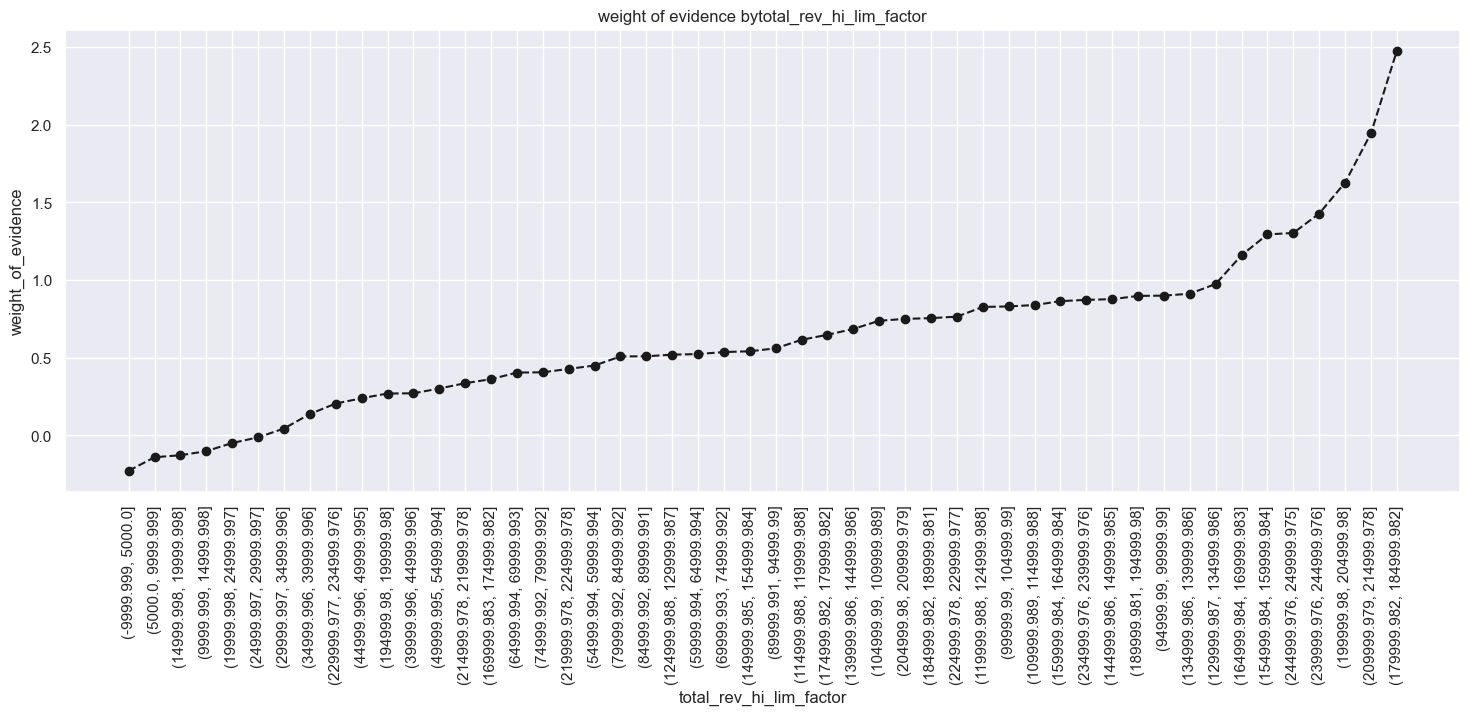

In [161]:
plot_by_woe(df_temp.iloc[: 50, : ], 90)

In [162]:
df_inputs_prepr['total_rev_hi_lim']=pd.to_numeric(df_inputs_prepr['total_rev_hi_lim'],errors='coerce')

In [163]:
df_inputs_prepr['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] <= 5000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 5000) & (df_inputs_prepr['total_rev_hi_lim'] <= 10000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:10K-20K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 10000) & (df_inputs_prepr['total_rev_hi_lim'] <= 20000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 20000) & (df_inputs_prepr['total_rev_hi_lim'] <= 30000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 30000) & (df_inputs_prepr['total_rev_hi_lim'] <= 40000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:40K-55K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 40000) & (df_inputs_prepr['total_rev_hi_lim'] <= 55000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:55K-95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 55000) & (df_inputs_prepr['total_rev_hi_lim'] <= 95000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:>95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 95000), 1, 0)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\1572597749.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] <= 5000), 1, 0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\1572597749.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 5000) & (df_inputs_prepr['total_rev_hi_lim'] <= 10000), 1, 0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_2355

In [164]:
df_inputs_prepr['installment_factor'] = pd.cut(df_inputs_prepr['installment'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'installment_factor', df_targets_prepr)
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\376730482.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['installment_factor'] = pd.cut(df_inputs_prepr['installment'], 50)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

,installment_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(14.276, 43.556]",1812,0.906181,0.004858,0.093819,1642.0,170.0,0.004942,0.004169,0.170127,1.315331e-04
1,"(43.556, 71.443]",4841,0.897542,0.012978,0.102458,4345.0,496.0,0.013078,0.012163,0.072460,6.623439e-05
2,"(71.443, 99.329]",6824,0.893025,0.018294,0.106975,6094.0,730.0,0.018342,0.017902,0.024270,1.067415e-05
3,"(99.329, 127.216]",9138,0.890348,0.024497,0.109652,8136.0,1002.0,0.024488,0.024572,-0.003444,2.910056e-07
4,"(127.216, 155.102]",10040,0.896514,0.026915,0.103486,9001.0,1039.0,0.027091,0.025479,0.061332,9.884391e-05
5,"(155.102, 182.988]",16816,0.894208,0.045080,0.105792,15037.0,1779.0,0.045258,0.043626,0.036717,5.990905e-05
6,"(182.988, 210.875]",17216,0.904798,0.046152,0.095202,15577.0,1639.0,0.046883,0.040193,0.153964,1.030040e-03
7,"(210.875, 238.761]",15090,0.900398,0.040453,0.099602,13587.0,1503.0,0.040894,0.036858,0.103905,4.193408e-04
8,"(238.761, 266.648]",18842,0.901391,0.050511,0.098609,16984.0,1858.0,0.051118,0.045564,0.115026,6.388952e-04
9,"(266.648, 294.534]",20100,0.891095,0.053883,0.108905,17911.0,2189.0,0.053908,0.053681,0.004225,9.603802e-07


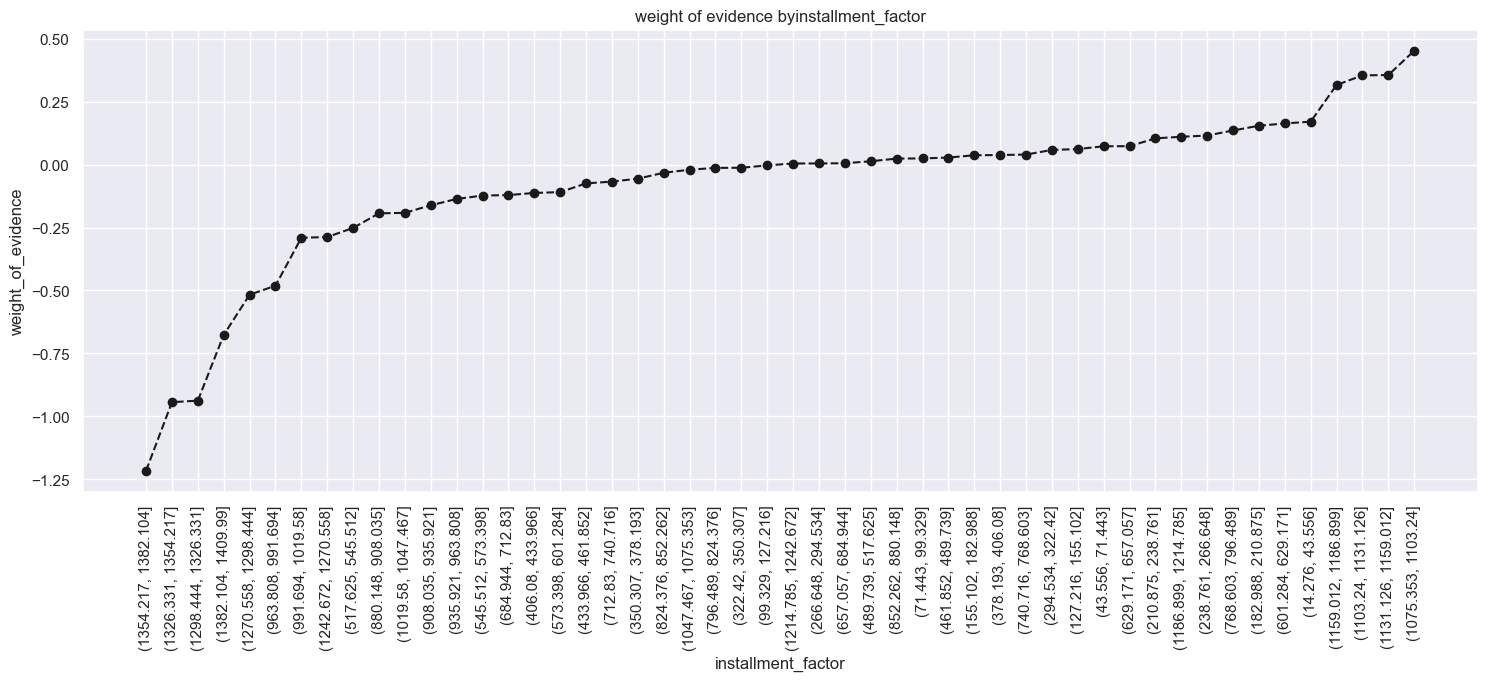

In [165]:
plot_by_woe(df_temp, 90)

In [166]:
df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 100)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'dti_factor', df_targets_prepr)
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3410334345.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 100)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pas

,dti_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(-0.04, 0.4]",745,0.876510,0.001997,0.123490,653.0,92.0,0.001965,0.002256,-0.137956,4.010821e-05
1,"(0.4, 0.8]",808,0.919554,0.002166,0.080446,743.0,65.0,0.002236,0.001594,0.338564,2.174497e-04
2,"(0.8, 1.2]",922,0.896963,0.002472,0.103037,827.0,95.0,0.002489,0.002330,0.066183,1.054967e-05
3,"(1.2, 1.6]",1043,0.896453,0.002796,0.103547,935.0,108.0,0.002814,0.002648,0.060670,1.005059e-05
4,"(1.6, 2.0]",1172,0.902730,0.003142,0.097270,1058.0,114.0,0.003184,0.002796,0.130192,5.060883e-05
5,"(2.0, 2.399]",1337,0.916978,0.003584,0.083022,1226.0,111.0,0.003690,0.002722,0.304237,2.944820e-04
6,"(2.399, 2.799]",1538,0.916125,0.004123,0.083875,1409.0,129.0,0.004241,0.003163,0.293078,3.157366e-04
7,"(2.799, 3.199]",1696,0.904481,0.004547,0.095519,1534.0,162.0,0.004617,0.003973,0.150293,9.682979e-05
8,"(3.199, 3.599]",1927,0.900363,0.005166,0.099637,1735.0,192.0,0.005222,0.004708,0.103522,5.316392e-05
9,"(3.599, 3.999]",2197,0.914429,0.005890,0.085571,2009.0,188.0,0.006047,0.004610,0.271205,3.895385e-04


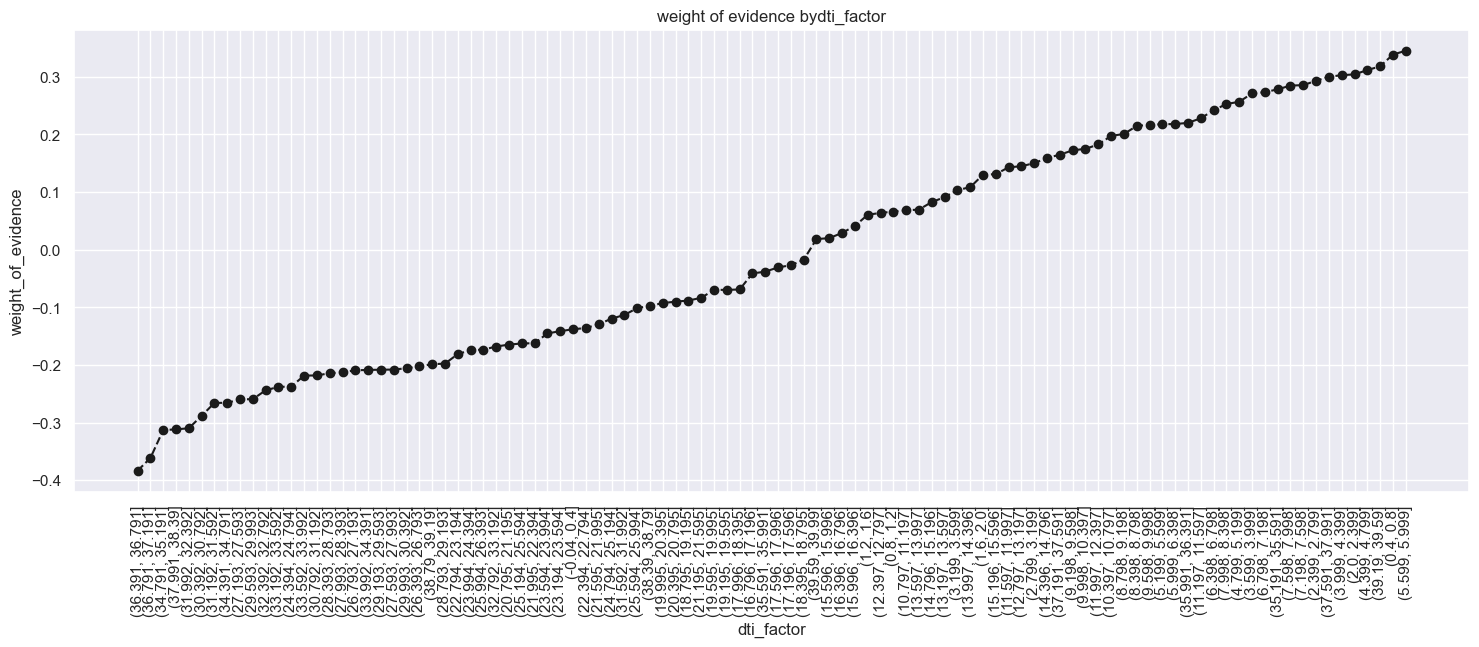

In [167]:
plot_by_woe(df_temp, 90)

In [168]:
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['dti'] <= 35, : ]

In [169]:
df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'dti_factor', df_targets_prepr.loc[df_inputs_prepr_temp.index])
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\1591369094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=pd.concat([df.groupby(df.columns.values[0],as_index=False)[df.columns.values[1]].count(),
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future ve

,dti_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(-0.035, 0.7]",1366,0.894583,0.003690,0.105417,1222.0,144.0,0.003707,0.003560,0.040465,5.948000e-06
1,"(0.7, 1.4]",1664,0.893029,0.004496,0.106971,1486.0,178.0,0.004507,0.004400,0.024094,2.585298e-06
2,"(1.4, 2.1]",1986,0.912890,0.005365,0.087110,1813.0,173.0,0.005499,0.004276,0.251481,3.074939e-04
3,"(2.1, 2.8]",2594,0.913261,0.007008,0.086739,2369.0,225.0,0.007186,0.005562,0.256157,4.159432e-04
4,"(2.8, 3.5]",3135,0.903030,0.008470,0.096970,2831.0,304.0,0.008587,0.007515,0.133392,1.430370e-04
5,"(3.5, 4.2]",3844,0.915713,0.010385,0.084287,3520.0,324.0,0.010677,0.008009,0.287507,7.670015e-04
6,"(4.2, 4.9]",4595,0.914037,0.012414,0.085963,4200.0,395.0,0.012739,0.009764,0.265988,7.913863e-04
7,"(4.9, 5.6]",5312,0.912651,0.014351,0.087349,4848.0,464.0,0.014705,0.011470,0.248471,8.038406e-04
8,"(5.6, 6.3]",5927,0.914797,0.016013,0.085203,5422.0,505.0,0.016446,0.012483,0.275696,1.092500e-03
9,"(6.3, 7.0]",6482,0.911601,0.017512,0.088399,5909.0,573.0,0.017923,0.014164,0.235381,8.847855e-04


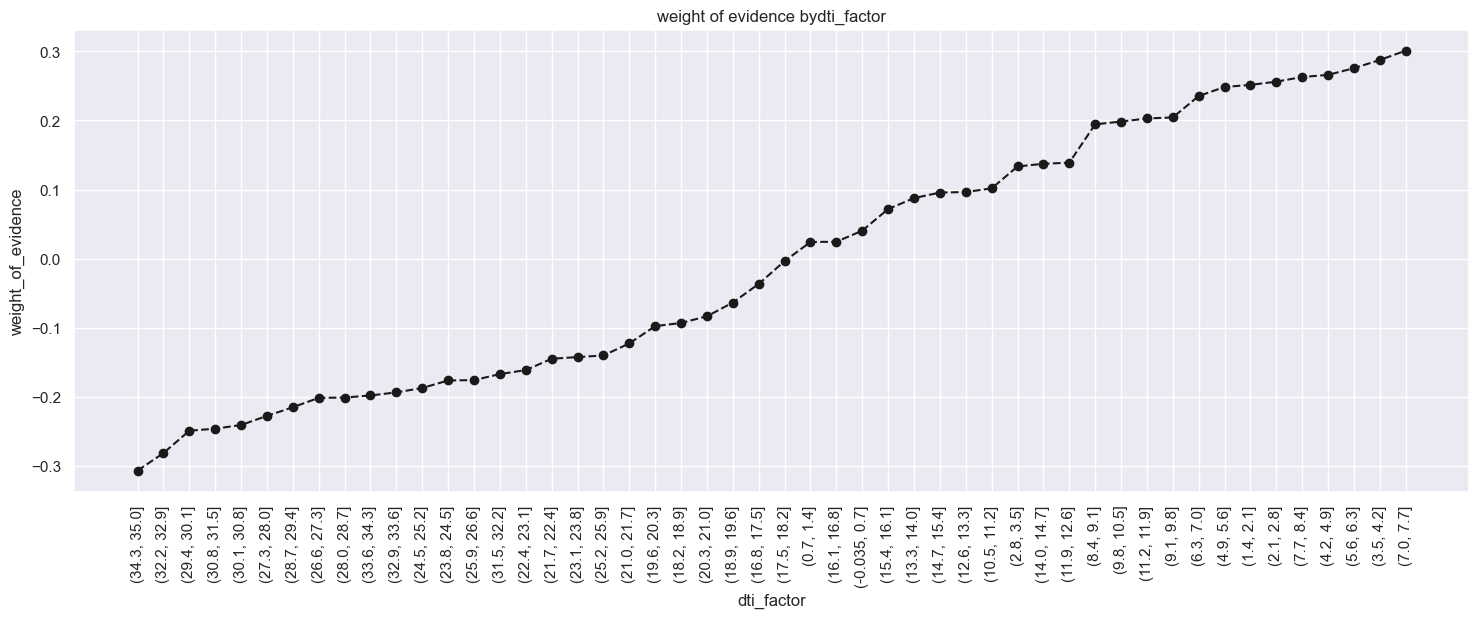

In [170]:
plot_by_woe(df_temp, 90)

In [171]:
df_inputs_prepr['dti']=pd.to_numeric(df_inputs_prepr['dti'],errors='coerce')

In [172]:
df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
df_inputs_prepr['dti:3.5-7.7'] = np.where((df_inputs_prepr['dti'] > 3.5) & (df_inputs_prepr['dti'] <= 7.7), 1, 0)
df_inputs_prepr['dti:7.7-10.5'] = np.where((df_inputs_prepr['dti'] > 7.7) & (df_inputs_prepr['dti'] <= 10.5), 1, 0)
df_inputs_prepr['dti:10.5-16.1'] = np.where((df_inputs_prepr['dti'] > 10.5) & (df_inputs_prepr['dti'] <= 16.1), 1, 0)
df_inputs_prepr['dti:16.1-20.3'] = np.where((df_inputs_prepr['dti'] > 16.1) & (df_inputs_prepr['dti'] <= 20.3), 1, 0)
df_inputs_prepr['dti:20.3-21.7'] = np.where((df_inputs_prepr['dti'] > 20.3) & (df_inputs_prepr['dti'] <= 21.7), 1, 0)
df_inputs_prepr['dti:21.7-22.4'] = np.where((df_inputs_prepr['dti'] > 21.7) & (df_inputs_prepr['dti'] <= 22.4), 1, 0)
df_inputs_prepr['dti:22.4-35'] = np.where((df_inputs_prepr['dti'] > 22.4) & (df_inputs_prepr['dti'] <= 35), 1, 0)
df_inputs_prepr['dti:>35'] = np.where((df_inputs_prepr['dti'] > 35), 1, 0)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3828360169.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3828360169.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3828360169.py:3: PerformanceWarning: DataFrame is highly fragment

In [173]:
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_record'])]
df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_record_factor', df_targets_prepr.loc[df_inputs_prepr_temp.index])
df_temp

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\1417292735.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\1417292735.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3073255706.py:3: 

,mths_since_last_record_factor,n_obs,prop_good,prop_n_obs,prop_bad,n_good,n_bad,dist_good,dist_bad,WOE,IV
0,"(-0.121, 2.42]",1086,0.764273,0.021691,0.235727,830.0,256.0,0.018569,0.047672,-0.942830,2.743898e-02
1,"(2.42, 4.84]",76,0.894737,0.001518,0.105263,68.0,8.0,0.001521,0.001490,0.020988,6.631477e-07
2,"(4.84, 7.26]",163,0.914110,0.003256,0.085890,149.0,14.0,0.003334,0.002607,0.245810,1.785766e-04
3,"(7.26, 9.68]",156,0.903846,0.003116,0.096154,141.0,15.0,0.003155,0.002793,0.121631,4.394269e-05
4,"(9.68, 12.1]",292,0.907534,0.005832,0.092466,265.0,27.0,0.005929,0.005028,0.164814,1.484775e-04
5,"(12.1, 14.52]",207,0.917874,0.004134,0.082126,190.0,17.0,0.004251,0.003166,0.294732,3.198166e-04
6,"(14.52, 16.94]",210,0.928571,0.004194,0.071429,195.0,15.0,0.004363,0.002793,0.445871,6.997555e-04
7,"(16.94, 19.36]",334,0.907186,0.006671,0.092814,303.0,31.0,0.006779,0.005773,0.160667,1.616579e-04
8,"(19.36, 21.78]",283,0.936396,0.005652,0.063604,265.0,18.0,0.005929,0.003352,0.570280,1.469527e-03
9,"(21.78, 24.2]",455,0.898901,0.009088,0.101099,409.0,46.0,0.009151,0.008566,0.065995,3.856726e-05


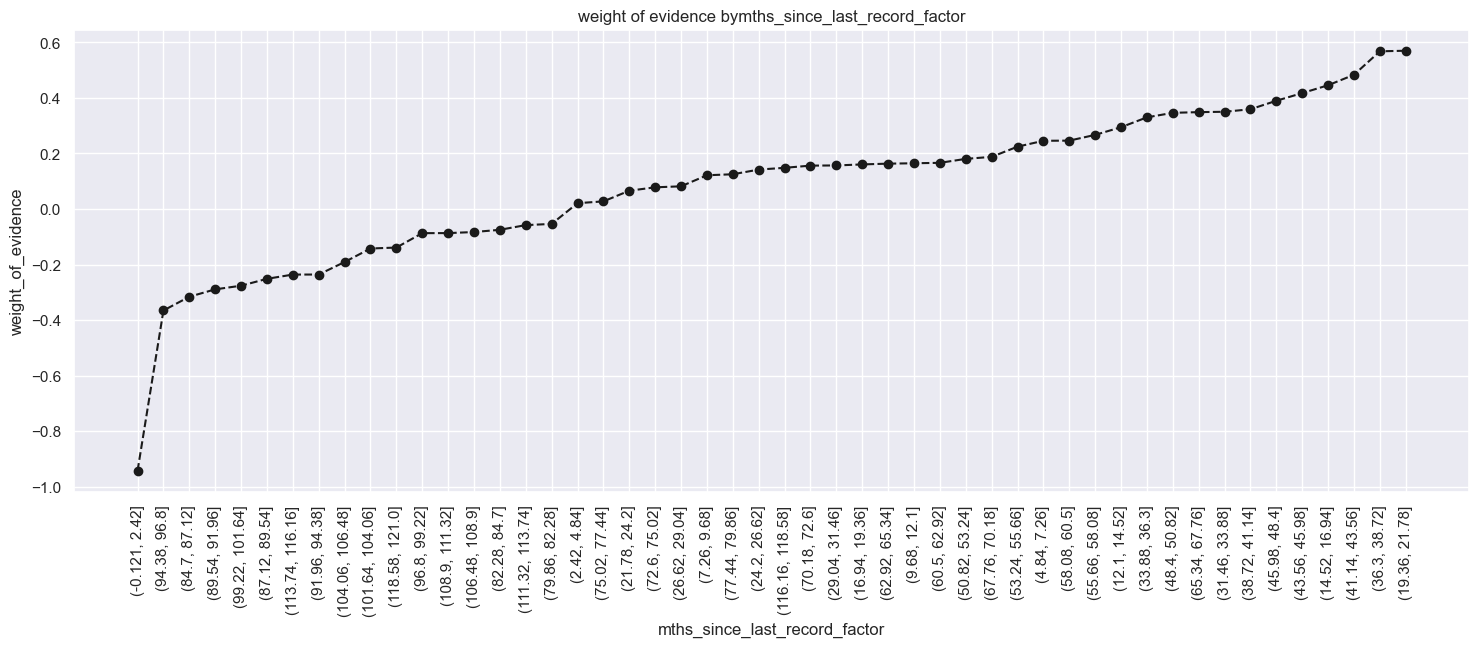

In [174]:
plot_by_woe(df_temp, 90)

In [175]:
df_inputs_prepr['mths_since_last_record']=pd.to_numeric(df_inputs_prepr['mths_since_last_record'],errors='coerce')

In [176]:
df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
df_inputs_prepr['mths_since_last_record:3-20'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 3) & (df_inputs_prepr['mths_since_last_record'] <= 20), 1, 0)
df_inputs_prepr['mths_since_last_record:21-31'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 21) & (df_inputs_prepr['mths_since_last_record'] <= 31), 1, 0)
df_inputs_prepr['mths_since_last_record:32-80'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 32) & (df_inputs_prepr['mths_since_last_record'] <= 80), 1, 0)
df_inputs_prepr['mths_since_last_record:81-86'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 81) & (df_inputs_prepr['mths_since_last_record'] <= 86), 1, 0)
df_inputs_prepr['mths_since_last_record:>=86'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 86), 1, 0)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3220700279.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3220700279.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
C:\Users\aswin\AppData\

In [177]:
loan_data_inputs_train.shape

(373028, 324)

In [178]:
loan_data_targets_test.shape

(93257, 1)

In [179]:
loan_data_targets_train.shape

(373028, 1)

In [180]:
loan_data_inputs_test.shape

(93257, 207)

In [181]:
missing_in_test=[col for col in loan_data_inputs_train.columns
                 if col not in loan_data_inputs_test.columns]
print(f"Missing columns in test:{len(missing_in_test)}")
print(missing_in_test)

Missing columns in test:117
['home_ownership:mortgage_other_none_any', 'addr_state=ND', 'addr_state:ND_NE_IA_NV_FL_HI_AL', 'addr_state:NM_VA', 'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:UT_KY_AZ_NJ', 'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 'addr_state:GA_WA_OR', 'addr_state:WI_MT', 'addr_state:IL_CT', 'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:WV_NH_WY_DC_ME_ID', 'term:36', 'term:60', 'emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6', 'emp_length:7-9', 'emp_length:10', 'month_since_issue_d_factor', 'month_since_issue_d:<38', 'month_since_issue_d:38-39', 'month_since_issue_d:40-41', 'month_since_issue_d:42-48', 'month_since_issue_d:49-52', 'month_since_issue_d:53-64', 'month_since_issue_d:65-84', 'month_since_issue_d:>85', 'int_rate_factor', 'int_rate:<9.548', 'int_rate:9.548-12.025', 'int_rate:12.025-15.74', 'int_rate:15.74-20.281', 'int_rate:>20.281', 'funded_amnt_factor', 'annual_inc_factor', 'annual_inc:<20k', 'annual_inc:20k-30k', 'annual_inc:30

In [182]:
loan_data_inputs_train.shape

(373028, 324)

In [183]:
df_inputs_prepr.shape

(373028, 324)

In [184]:
loan_data_inputs_test.shape

(93257, 207)

In [185]:
loan_data_inputs_train.columns.difference(loan_data_inputs_test.columns)[:20]

Index(['acc_now_delinq:0', 'acc_now_delinq:>=1', 'addr_state:AR_MI_PA_OH_MN',
       'addr_state:GA_WA_OR', 'addr_state:IL_CT',
       'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:ND_NE_IA_NV_FL_HI_AL',
       'addr_state:NM_VA', 'addr_state:OK_TN_MO_LA_MD_NC',
       'addr_state:RI_MA_DE_SD_IN', 'addr_state:UT_KY_AZ_NJ',
       'addr_state:WI_MT', 'addr_state:WV_NH_WY_DC_ME_ID', 'addr_state=ND',
       'annual_inc:100k-120k', 'annual_inc:120k-140k', 'annual_inc:20k-30k',
       'annual_inc:30k-40k', 'annual_inc:40k-50k', 'annual_inc:50k-60k'],
      dtype='object')

In [186]:
df_inputs_prepr_test = loan_data_inputs_test.copy()

In [187]:
df_inputs_prepr_test['annual_inc:<20k']=np.where((df_inputs_prepr_test['annual_inc']<=20000),1,0)
df_inputs_prepr_test['annual_inc:20k-30k']=np.where((df_inputs_prepr_test['annual_inc']>20000)&(df_inputs_prepr_test['annual_inc']<=30000),1,0)
df_inputs_prepr_test['annual_inc:30k-40k']=np.where((df_inputs_prepr_test['annual_inc']>30000)&(df_inputs_prepr_test['annual_inc']<=40000),1,0)
df_inputs_prepr_test['annual_inc:40k-50k']=np.where((df_inputs_prepr_test['annual_inc']>40000)&(df_inputs_prepr_test['annual_inc']<=50000),1,0)
df_inputs_prepr_test['annual_inc:50k-60k']=np.where((df_inputs_prepr_test['annual_inc']>50000)&(df_inputs_prepr_test['annual_inc']<=60000),1,0)
df_inputs_prepr_test['annual_inc:60k-70k']=np.where((df_inputs_prepr_test['annual_inc']>60000)&(df_inputs_prepr_test['annual_inc']<=70000),1,0)
df_inputs_prepr_test['annual_inc:70k-80k']=np.where((df_inputs_prepr_test['annual_inc']>70000)&(df_inputs_prepr_test['annual_inc']<=80000),1,0)
df_inputs_prepr_test['annual_inc:80k-90k']=np.where((df_inputs_prepr_test['annual_inc']>80000)&(df_inputs_prepr_test['annual_inc']<=90000),1,0)
df_inputs_prepr_test['annual_inc:90k-100k']=np.where((df_inputs_prepr_test['annual_inc']>90000)&(df_inputs_prepr_test['annual_inc']<=100000),1,0)
df_inputs_prepr_test['annual_inc:100k-120k']=np.where((df_inputs_prepr_test['annual_inc']>100000)&(df_inputs_prepr_test['annual_inc']<=120000),1,0)
df_inputs_prepr_test['annual_inc:120k-140k']=np.where((df_inputs_prepr_test['annual_inc']>120000)&(df_inputs_prepr_test['annual_inc']<=140000),1,0)
df_inputs_prepr_test['annual_inc:>140k']=np.where((df_inputs_prepr_test['annual_inc']>140000),1,0)

In [188]:
loan_data_inputs_test.shape

(93257, 207)

In [189]:
df_inputs_prepr_test.shape

(93257, 219)

In [190]:
df_inputs_prepr_test['addr_state:ND_NE_IA_NV_FL_HI_AL']=(df_inputs_prepr_test['addr_state:NE']+ df_inputs_prepr_test['addr_state:IA']+df_inputs_prepr_test['addr_state:NV']+df_inputs_prepr_test['addr_state:FL']+df_inputs_prepr_test['addr_state:HI']+df_inputs_prepr_test['addr_state:AL'])
df_inputs_prepr_test['addr_state:NM_VA']=(df_inputs_prepr_test['addr_state:NM']+ df_inputs_prepr_test['addr_state:VA'])
df_inputs_prepr_test['addr_state:OK_TN_MO_LA_MD_NC']=(df_inputs_prepr_test['addr_state:OK']+ df_inputs_prepr_test['addr_state:TN']+df_inputs_prepr_test['addr_state:MO']+df_inputs_prepr_test['addr_state:LA']+df_inputs_prepr_test['addr_state:MD']+df_inputs_prepr_test['addr_state:NC'])
df_inputs_prepr_test['addr_state:UT_KY_AZ_NJ']=(df_inputs_prepr_test['addr_state:UT']+ df_inputs_prepr_test['addr_state:KY']+df_inputs_prepr_test['addr_state:AZ']+df_inputs_prepr_test['addr_state:NJ'])
df_inputs_prepr_test['addr_state:AR_MI_PA_OH_MN']=(df_inputs_prepr_test['addr_state:AR']+ df_inputs_prepr_test['addr_state:MI']+df_inputs_prepr_test['addr_state:PA']+df_inputs_prepr_test['addr_state:OH']+df_inputs_prepr_test['addr_state:MN'])
df_inputs_prepr_test['addr_state:RI_MA_DE_SD_IN']=(df_inputs_prepr_test['addr_state:RI']+ df_inputs_prepr_test['addr_state:MA']+df_inputs_prepr_test['addr_state:DE']+df_inputs_prepr_test['addr_state:SD']+df_inputs_prepr_test['addr_state:IN'])
df_inputs_prepr_test['addr_state:GA_WA_OR']=(df_inputs_prepr_test['addr_state:GA']+ df_inputs_prepr_test['addr_state:WA']+df_inputs_prepr_test['addr_state:OR'])
df_inputs_prepr_test['addr_state:WI_MT']=(df_inputs_prepr_test['addr_state:WI']+ df_inputs_prepr_test['addr_state:MT'])
df_inputs_prepr_test['addr_state:IL_CT']=(df_inputs_prepr_test['addr_state:IL']+ df_inputs_prepr_test['addr_state:CT'])
df_inputs_prepr_test['addr_state:KS_SC_CO_VT_AK_MS']=(df_inputs_prepr_test['addr_state:KS']+ df_inputs_prepr_test['addr_state:SC']+df_inputs_prepr_test['addr_state:CO']+df_inputs_prepr_test['addr_state:VT']+df_inputs_prepr_test['addr_state:AK']+df_inputs_prepr_test['addr_state:MS'])
df_inputs_prepr_test['addr_state:WV_NH_WY_DC_ME_ID']=(df_inputs_prepr_test['addr_state:WV']+ df_inputs_prepr_test['addr_state:NH']+df_inputs_prepr_test['addr_state:WY']+df_inputs_prepr_test['addr_state:DC']+df_inputs_prepr_test['addr_state:ME']+df_inputs_prepr_test['addr_state:ID'])


In [191]:
df_inputs_prepr_test['home_ownership:mortgage_other_none_any']=(df_inputs_prepr_test['home_ownership:MORTGAGE']+df_inputs_prepr_test['home_ownership:OTHER']+ df_inputs_prepr_test['home_ownership:NONE']+df_inputs_prepr_test['home_ownership:ANY'])

In [192]:
df_inputs_prepr_test['term:36']=np.where((df_inputs_prepr_test['term_int']==36),1,0)
df_inputs_prepr_test['term:60']=np.where((df_inputs_prepr_test['term_int']==60),1,0)

In [193]:
df_inputs_prepr_test['month_since_issue_d:<38']=np.where(df_inputs_prepr_test['month_since_issue_d'].isin(range(38)),1,0)
df_inputs_prepr_test['month_since_issue_d:38-39']=np.where(df_inputs_prepr_test['month_since_issue_d'].isin(range(38,40)),1,0)
df_inputs_prepr_test['month_since_issue_d:40-41']=np.where(df_inputs_prepr_test['month_since_issue_d'].isin(range(40,42)),1,0)
df_inputs_prepr_test['month_since_issue_d:42-48']=np.where(df_inputs_prepr_test['month_since_issue_d'].isin(range(42,49)),1,0)
df_inputs_prepr_test['month_since_issue_d:49-52']=np.where(df_inputs_prepr_test['month_since_issue_d'].isin(range(49,53)),1,0)
df_inputs_prepr_test['month_since_issue_d:53-64']=np.where(df_inputs_prepr_test['month_since_issue_d'].isin(range(53,65)),1,0)
df_inputs_prepr_test['month_since_issue_d:65-84']=np.where(df_inputs_prepr_test['month_since_issue_d'].isin(range(65,85)),1,0)
df_inputs_prepr_test['month_since_issue_d:>85']=np.where(df_inputs_prepr_test['month_since_issue_d'].isin(range(85, int(df_inputs_prepr_test['month_since_issue_d'].max()))),1,0)

In [194]:
df_inputs_prepr_test['int_rate:<9.548']=np.where((df_inputs_prepr_test['int_rate']<=9.548),1,0)
df_inputs_prepr_test['int_rate:9.548-12.025']=np.where((df_inputs_prepr_test['int_rate']>9.548)&(df_inputs_prepr_test['int_rate']<12.025),1,0)
df_inputs_prepr_test['int_rate:12.025-15.74'] = np.where((df_inputs_prepr_test['int_rate'] > 12.025) & (df_inputs_prepr_test['int_rate'] <= 15.74), 1, 0)
df_inputs_prepr_test['int_rate:15.74-20.281']=np.where((df_inputs_prepr_test['int_rate']>15.74)&(df_inputs_prepr_test['int_rate']<20.281),1,0)
df_inputs_prepr_test['int_rate:>20.281']=np.where((df_inputs_prepr_test['int_rate']>20.281),1,0)

In [195]:
df_inputs_prepr_test['funded_amnt_factor']=pd.cut(df_inputs_prepr_test['funded_amnt'],50)

In [196]:
df_inputs_prepr_test['mths_since_last_delinq:Missing']=np.where((df_inputs_prepr_test['mths_since_last_delinq'].isnull()),1,0)
df_inputs_prepr_test['mths_since_last_delinq:0-3']=np.where((df_inputs_prepr_test['mths_since_last_delinq']>=0)&(df_inputs_prepr_test['mths_since_last_delinq']<=3),1,0)
df_inputs_prepr_test['mths_since_last_delinq:4-30']=np.where((df_inputs_prepr_test['mths_since_last_delinq']>=4)&(df_inputs_prepr_test['mths_since_last_delinq']<=30),1,0)
df_inputs_prepr_test['mths_since_last_delinq:31-56']=np.where((df_inputs_prepr_test['mths_since_last_delinq']>=31)&(df_inputs_prepr_test['mths_since_last_delinq']<=56),1,0)
df_inputs_prepr_test['mths_since_last_delinq:>=57']=np.where((df_inputs_prepr_test['mths_since_last_delinq']>=57),1,0)


In [197]:
df_inputs_prepr_test['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([df_inputs_prepr_test['purpose:educational'], df_inputs_prepr_test['purpose:small_business'],
                                                                 df_inputs_prepr_test['purpose:wedding'], df_inputs_prepr_test['purpose:renewable_energy'],
                                                                 df_inputs_prepr_test['purpose:moving'], df_inputs_prepr_test['purpose:house']])
df_inputs_prepr_test['purpose:oth__med__vacation'] = sum([df_inputs_prepr_test['purpose:other'], df_inputs_prepr_test['purpose:medical'],
                                             df_inputs_prepr_test['purpose:vacation']])
df_inputs_prepr_test['purpose:major_purch__car__home_impr'] = sum([df_inputs_prepr_test['purpose:major_purchase'], df_inputs_prepr_test['purpose:car'],
                                                        df_inputs_prepr_test['purpose:home_improvement']])

In [198]:
df_inputs_prepr_test['month_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr_test['month_since_earliest_cr_line'], 50)

In [199]:
df_inputs_prepr_test['month_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr_test['month_since_earliest_cr_line'].isin(range(140)), 1, 0)
df_inputs_prepr_test['month_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr_test['month_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)
df_inputs_prepr_test['month_since_earliest_cr_line:165-247'] = np.where(df_inputs_prepr_test['month_since_earliest_cr_line'].isin(range(165, 248)), 1, 0)
df_inputs_prepr_test['month_since_earliest_cr_line:248-270'] = np.where(df_inputs_prepr_test['month_since_earliest_cr_line'].isin(range(248, 271)), 1, 0)
df_inputs_prepr_test['month_since_earliest_cr_line:271-352'] = np.where(df_inputs_prepr_test['month_since_earliest_cr_line'].isin(range(271, 353)), 1, 0)
df_inputs_prepr_test['month_since_earliest_cr_line:>352'] = np.where(df_inputs_prepr_test['month_since_earliest_cr_line'].isin(range(353, int(df_inputs_prepr_test['month_since_earliest_cr_line'].max()))), 1, 0)

In [200]:
df_inputs_prepr_test['delinq_2yrs']=pd.to_numeric(df_inputs_prepr_test['delinq_2yrs'],errors='coerce')

In [201]:
df_inputs_prepr_test['delinq_2yrs:0'] = np.where((df_inputs_prepr_test['delinq_2yrs'] == 0), 1, 0)
df_inputs_prepr_test['delinq_2yrs:1-3'] = np.where((df_inputs_prepr_test['delinq_2yrs'] >= 1) & (df_inputs_prepr_test['delinq_2yrs'] <= 3), 1, 0)
df_inputs_prepr_test['delinq_2yrs:>=4'] = np.where((df_inputs_prepr_test['delinq_2yrs'] >= 4), 1, 0)

In [202]:
df_inputs_prepr_test['inq_last_6mths'] =pd.to_numeric(df_inputs_prepr_test['inq_last_6mths'],errors='coerce')

In [203]:
df_inputs_prepr_test['inq_last_6mths:0'] = np.where((df_inputs_prepr_test['inq_last_6mths'] == 0), 1, 0)
df_inputs_prepr_test['inq_last_6mths:1-2'] = np.where((df_inputs_prepr_test['inq_last_6mths'] >= 1) & (df_inputs_prepr_test['inq_last_6mths'] <= 2), 1, 0)
df_inputs_prepr_test['inq_last_6mths:3-6'] = np.where((df_inputs_prepr_test['inq_last_6mths'] >= 3) & (df_inputs_prepr_test['inq_last_6mths'] <= 6), 1, 0)
df_inputs_prepr_test['inq_last_6mths:>6'] = np.where((df_inputs_prepr_test['inq_last_6mths'] > 6), 1, 0)

In [204]:
df_inputs_prepr_test['open_acc']=pd.to_numeric(df_inputs_prepr_test['open_acc'],errors='coerce')

In [205]:
df_inputs_prepr_test['open_acc:0'] = np.where((df_inputs_prepr_test['open_acc'] == 0), 1, 0)
df_inputs_prepr_test['open_acc:1-3'] = np.where((df_inputs_prepr_test['open_acc'] >= 1) & (df_inputs_prepr_test['open_acc'] <= 3), 1, 0)
df_inputs_prepr_test['open_acc:4-12'] = np.where((df_inputs_prepr_test['open_acc'] >= 4) & (df_inputs_prepr_test['open_acc'] <= 12), 1, 0)
df_inputs_prepr_test['open_acc:13-17'] = np.where((df_inputs_prepr_test['open_acc'] >= 13) & (df_inputs_prepr_test['open_acc'] <= 17), 1, 0)
df_inputs_prepr_test['open_acc:18-22'] = np.where((df_inputs_prepr_test['open_acc'] >= 18) & (df_inputs_prepr_test['open_acc'] <= 22), 1, 0)
df_inputs_prepr_test['open_acc:23-25'] = np.where((df_inputs_prepr_test['open_acc'] >= 23) & (df_inputs_prepr_test['open_acc'] <= 25), 1, 0)
df_inputs_prepr_test['open_acc:26-30'] = np.where((df_inputs_prepr_test['open_acc'] >= 26) & (df_inputs_prepr_test['open_acc'] <= 30), 1, 0)
df_inputs_prepr_test['open_acc:>=31'] = np.where((df_inputs_prepr_test['open_acc'] >= 31), 1, 0)

In [206]:
df_inputs_prepr_test['pub_rec']=pd.to_numeric(df_inputs_prepr_test['pub_rec'],errors='coerce')

In [207]:
df_inputs_prepr_test['pub_rec:0-2'] = np.where((df_inputs_prepr_test['pub_rec'] >= 0) & (df_inputs_prepr_test['pub_rec'] <= 2), 1, 0)
df_inputs_prepr_test['pub_rec:3-4'] = np.where((df_inputs_prepr_test['pub_rec'] >= 3) & (df_inputs_prepr_test['pub_rec'] <= 4), 1, 0)
df_inputs_prepr_test['pub_rec:>=5'] = np.where((df_inputs_prepr_test['pub_rec'] >= 5), 1, 0)

In [208]:
df_inputs_prepr_test['total_acc']=pd.to_numeric(df_inputs_prepr_test['total_acc'],errors='coerce')

In [209]:
df_inputs_prepr_test['total_acc_factor'] = pd.cut(df_inputs_prepr_test['total_acc'], 50)

In [210]:
df_inputs_prepr_test['total_acc:<=27'] = np.where((df_inputs_prepr_test['total_acc'] <= 27), 1, 0)
df_inputs_prepr_test['total_acc:28-51'] = np.where((df_inputs_prepr_test['total_acc'] >= 28) & (df_inputs_prepr_test['total_acc'] <= 51), 1, 0)
df_inputs_prepr_test['total_acc:>=52'] = np.where((df_inputs_prepr_test['total_acc'] >= 52), 1, 0)

In [211]:
df_inputs_prepr_test['acc_now_delinq']=pd.to_numeric(df_inputs_prepr_test['acc_now_delinq'],errors='coerce')

In [212]:
df_inputs_prepr_test['acc_now_delinq:0'] = np.where((df_inputs_prepr_test['acc_now_delinq'] == 0), 1, 0)
df_inputs_prepr_test['acc_now_delinq:>=1'] = np.where((df_inputs_prepr_test['acc_now_delinq'] >= 1), 1, 0)

In [213]:
df_inputs_prepr_test['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr_test['total_rev_hi_lim'], 2000)

In [214]:
df_inputs_prepr_test['total_rev_hi_lim']=pd.to_numeric(df_inputs_prepr_test['total_rev_hi_lim'],errors='coerce')

In [215]:
df_inputs_prepr_test['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] <= 5000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 5000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 10000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:10K-20K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 10000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 20000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 20000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 30000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 30000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 40000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:40K-55K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 40000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 55000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:55K-95K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 55000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 95000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:>95K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 95000), 1, 0)

In [216]:
df_inputs_prepr_test['installment_factor'] = pd.cut(df_inputs_prepr_test['installment'], 50)

In [217]:
df_inputs_prepr_test['dti_factor'] = pd.cut(df_inputs_prepr_test['dti'], 100)

In [218]:
df_inputs_prepr_test['dti']=pd.to_numeric(df_inputs_prepr_test['dti'],errors='coerce')

In [219]:
df_inputs_prepr_test['dti:<=1.4'] = np.where((df_inputs_prepr_test['dti'] <= 1.4), 1, 0)
df_inputs_prepr_test['dti:1.4-3.5'] = np.where((df_inputs_prepr_test['dti'] > 1.4) & (df_inputs_prepr_test['dti'] <= 3.5), 1, 0)
df_inputs_prepr_test['dti:3.5-7.7'] = np.where((df_inputs_prepr_test['dti'] > 3.5) & (df_inputs_prepr_test['dti'] <= 7.7), 1, 0)
df_inputs_prepr_test['dti:7.7-10.5'] = np.where((df_inputs_prepr_test['dti'] > 7.7) & (df_inputs_prepr_test['dti'] <= 10.5), 1, 0)
df_inputs_prepr_test['dti:10.5-16.1'] = np.where((df_inputs_prepr_test['dti'] > 10.5) & (df_inputs_prepr_test['dti'] <= 16.1), 1, 0)
df_inputs_prepr_test['dti:16.1-20.3'] = np.where((df_inputs_prepr_test['dti'] > 16.1) & (df_inputs_prepr_test['dti'] <= 20.3), 1, 0)
df_inputs_prepr_test['dti:20.3-21.7'] = np.where((df_inputs_prepr_test['dti'] > 20.3) & (df_inputs_prepr_test['dti'] <= 21.7), 1, 0)
df_inputs_prepr_test['dti:21.7-22.4'] = np.where((df_inputs_prepr_test['dti'] > 21.7) & (df_inputs_prepr_test['dti'] <= 22.4), 1, 0)
df_inputs_prepr_test['dti:22.4-35'] = np.where((df_inputs_prepr_test['dti'] > 22.4) & (df_inputs_prepr_test['dti'] <= 35), 1, 0)
df_inputs_prepr_test['dti:>35'] = np.where((df_inputs_prepr_test['dti'] > 35), 1, 0)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\2644956674.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['dti:<=1.4'] = np.where((df_inputs_prepr_test['dti'] <= 1.4), 1, 0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\2644956674.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['dti:1.4-3.5'] = np.where((df_inputs_prepr_test['dti'] > 1.4) & (df_inputs_prepr_test['dti'] <= 3.5), 1, 0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\2644956674.py:3: PerformanceWarning: Dat

In [220]:
df_inputs_prepr_test['mths_since_last_record']=pd.to_numeric(df_inputs_prepr_test['mths_since_last_record'],errors='coerce')

In [221]:
df_inputs_prepr_test['mths_since_last_record:Missing'] = np.where((df_inputs_prepr_test['mths_since_last_record'].isnull()), 1, 0)
df_inputs_prepr_test['mths_since_last_record:0-2'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 0) & (df_inputs_prepr_test['mths_since_last_record'] <= 2), 1, 0)
df_inputs_prepr_test['mths_since_last_record:3-20'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 3) & (df_inputs_prepr_test['mths_since_last_record'] <= 20), 1, 0)
df_inputs_prepr_test['mths_since_last_record:21-31'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 21) & (df_inputs_prepr_test['mths_since_last_record'] <= 31), 1, 0)
df_inputs_prepr_test['mths_since_last_record:32-80'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 32) & (df_inputs_prepr_test['mths_since_last_record'] <= 80), 1, 0)
df_inputs_prepr_test['mths_since_last_record:81-86'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 81) & (df_inputs_prepr_test['mths_since_last_record'] <= 86), 1, 0)
df_inputs_prepr_test['mths_since_last_record:>=86'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 86), 1, 0)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\2089194066.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_last_record:Missing'] = np.where((df_inputs_prepr_test['mths_since_last_record'].isnull()), 1, 0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\2089194066.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_last_record:0-2'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 0) & (df_inputs_prepr_test['mths_since_last_record'] <= 2), 1, 0

In [222]:
df_inputs_prepr_test.shape

(93257, 314)

In [223]:
df_inputs_prepr_test['month_since_issue_d_factor']=pd.cut(df_inputs_prepr_test['month_since_issue_d'],50)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3044519301.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['month_since_issue_d_factor']=pd.cut(df_inputs_prepr_test['month_since_issue_d'],50)


In [224]:
df_inputs_prepr_test['int_rate_factor']=pd.cut(df_inputs_prepr_test['int_rate'],50)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\1749450228.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['int_rate_factor']=pd.cut(df_inputs_prepr_test['int_rate'],50)


In [225]:
df_inputs_prepr_test['annual_inc_factor']=pd.cut(annual_inc_capped,50)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\3806533349.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['annual_inc_factor']=pd.cut(annual_inc_capped,50)


In [226]:
if['addr_state=ND']in df_inputs_prepr_test.columns.values:
    pass
else:
    df_inputs_prepr_test['addr_state=ND']=0


C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\1551365039.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['addr_state=ND']=0


In [227]:
missing_in_test=[col for col in loan_data_inputs_train.columns
                 if col not in df_inputs_prepr_test.columns]
print(f"Missing columns in test:{len(missing_in_test)}")
print(missing_in_test)

Missing columns in test:6
['emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6', 'emp_length:7-9', 'emp_length:10']


In [228]:
loan_data_inputs_test = df_inputs_prepr_test.copy()

In [229]:
loan_data_inputs_test.shape

(93257, 318)

In [230]:
loan_data_inputs_train.to_csv('loan_data_inputs_train.csv',index=False)
loan_data_targets_train.to_csv('loan_data_targets_train.csv',index=False)
loan_data_inputs_test.to_csv('loan_data_inputs_test.csv',index=False)
loan_data_targets_test.to_csv('loan_data_targets_test.csv',index=False)

In [231]:
[col for col in loan_data_inputs_train.columns if 'grade' in col]

['grade',
 'sub_grade',
 'grade:A',
 'grade:B',
 'grade:C',
 'grade:D',
 'grade:E',
 'grade:F',
 'grade:G',
 'sub_grade:A1',
 'sub_grade:A2',
 'sub_grade:A3',
 'sub_grade:A4',
 'sub_grade:A5',
 'sub_grade:B1',
 'sub_grade:B2',
 'sub_grade:B3',
 'sub_grade:B4',
 'sub_grade:B5',
 'sub_grade:C1',
 'sub_grade:C2',
 'sub_grade:C3',
 'sub_grade:C4',
 'sub_grade:C5',
 'sub_grade:D1',
 'sub_grade:D2',
 'sub_grade:D3',
 'sub_grade:D4',
 'sub_grade:D5',
 'sub_grade:E1',
 'sub_grade:E2',
 'sub_grade:E3',
 'sub_grade:E4',
 'sub_grade:E5',
 'sub_grade:F1',
 'sub_grade:F2',
 'sub_grade:F3',
 'sub_grade:F4',
 'sub_grade:F5',
 'sub_grade:G1',
 'sub_grade:G2',
 'sub_grade:G3',
 'sub_grade:G4',
 'sub_grade:G5']

In [232]:
print('grade:A' in loan_data_inputs_train.columns)
print('grade:G' in loan_data_inputs_train.columns)

True
True


In [233]:
missing_cols = sorted(
    set(df_inputs_prepr.columns) - set(df_inputs_prepr_test.columns)
)

print("Missing:", len(missing_cols))
for col in missing_cols:
    print(col)

Missing: 6
emp_length:0
emp_length:1
emp_length:10
emp_length:2-4
emp_length:5-6
emp_length:7-9


In [234]:
[col for col in loan_data_inputs_train.columns if 'emp_length' in col]

['emp_length',
 'emp_length_int',
 'emp_length:0',
 'emp_length:1',
 'emp_length:2-4',
 'emp_length:5-6',
 'emp_length:7-9',
 'emp_length:10']

In [235]:
[col for col in loan_data_inputs_train.columns if 'emp_length' in col]

['emp_length',
 'emp_length_int',
 'emp_length:0',
 'emp_length:1',
 'emp_length:2-4',
 'emp_length:5-6',
 'emp_length:7-9',
 'emp_length:10']

In [236]:
df_inputs_prepr_test['emp_length:0']=np.where(df_inputs_prepr_test['emp_length_int'].isin([0]),1,0)
df_inputs_prepr_test['emp_length:1']=np.where(df_inputs_prepr_test['emp_length_int'].isin([1]),1,0)
df_inputs_prepr_test['emp_length:2-4']=np.where(df_inputs_prepr_test['emp_length_int'].isin(range(2,4)),1,0)
df_inputs_prepr_test['emp_length:5-6']=np.where(df_inputs_prepr_test['emp_length_int'].isin(range(5,6)),1,0)
df_inputs_prepr_test['emp_length:7-9']=np.where(df_inputs_prepr_test['emp_length_int'].isin(range(7,9)),1,0)
df_inputs_prepr_test['emp_length:10']=np.where(df_inputs_prepr_test['emp_length_int'].isin([10]),1,0)

C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\4047609742.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['emp_length:0']=np.where(df_inputs_prepr_test['emp_length_int'].isin([0]),1,0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\4047609742.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['emp_length:1']=np.where(df_inputs_prepr_test['emp_length_int'].isin([1]),1,0)
C:\Users\aswin\AppData\Local\Temp\ipykernel_23556\4047609742.py:3: PerformanceWarning: DataFrame is highly f

In [244]:
loan_data_inputs_test = df_inputs_prepr_test.copy()

In [245]:
loan_data_inputs_train.to_csv('loan_data_inputs_train.csv',index=False)
loan_data_targets_train.to_csv('loan_data_targets_train.csv',index=False)
loan_data_inputs_test.to_csv('loan_data_inputs_test.csv',index=False)
loan_data_targets_test.to_csv('loan_data_targets_test.csv',index=False)

In [246]:
    [col for col in df_inputs_prepr.columns if 'annual_inc:' in col]

['annual_inc:<20k',
 'annual_inc:20k-30k',
 'annual_inc:30k-40k',
 'annual_inc:40k-50k',
 'annual_inc:50k-60k',
 'annual_inc:60k-70k',
 'annual_inc:70k-80k',
 'annual_inc:80k-90k',
 'annual_inc:90k-100k',
 'annual_inc:100k-120k',
 'annual_inc:120k-140k',
 'annual_inc:>140k']

In [247]:
[col for col in df_inputs_prepr_test.columns if 'annual_inc:' in col]

['annual_inc:<20k',
 'annual_inc:20k-30k',
 'annual_inc:30k-40k',
 'annual_inc:40k-50k',
 'annual_inc:50k-60k',
 'annual_inc:60k-70k',
 'annual_inc:70k-80k',
 'annual_inc:80k-90k',
 'annual_inc:90k-100k',
 'annual_inc:100k-120k',
 'annual_inc:120k-140k',
 'annual_inc:>140k']

In [248]:
'emp_length:0' in df_inputs_prepr_test.columns
'emp_length:0' in loan_data_inputs_test.columns

True

In [249]:
[col for col in df_inputs_prepr_test.columns if 'emp_length' in col]

['emp_length',
 'emp_length_int',
 'emp_length:0',
 'emp_length:1',
 'emp_length:2-4',
 'emp_length:5-6',
 'emp_length:7-9',
 'emp_length:10']

In [250]:
print(df_inputs_prepr_test.shape)


(93257, 324)


In [251]:
loan_data_inputs_test.shape

(93257, 324)